# **Flight Fare Prediction**

---------------------------------------------

![Flight](https://images.unsplash.com/photo-1569154941061-e231b4725ef1?w=1600&h=500&fit=crop)

##### **Project Type**    -   Supervised ML(Regression)
##### **Contribution**    -   Individual
##### **NAME**            -   Harshitha Pethuraj
##### **TEAM ID**         -   Team PTID-AIE-MAY-26-11194 - AIE

# **Project Summary -**

The airline industry is one of the most dynamic sectors in the world, where ticket prices fluctuate constantly based on a wide range of factors such as airline, source, destination, departure time, duration, number of stops, and date of journey. For travelers, this unpredictability often makes it difficult to decide the right time to book a flight, while for airlines and travel agencies, accurate fare prediction plays a crucial role in pricing strategy and revenue management.

Flight Fare Prediction is a supervised machine learning approach that uses historical flight booking data to predict the future price of a flight ticket based on its features. The model learns hidden patterns and relationships between various attributes of a flight — such as the airline, source and destination cities, journey date, departure and arrival timings, total duration, and number of stops — and the corresponding ticket price. Once trained, the model can estimate the fare of a new flight given the same input attributes, helping users make informed booking decisions and helping businesses forecast pricing trends.

The dataset used in this project contains 10,683 records of Indian domestic flights covering March to June 2019. Since the raw data contained dates, times, and durations in string format, a significant portion of the project involved feature engineering — extracting components such as journey day, month, weekday, weekend indicator, departure and arrival hours, time buckets, and duration in minutes — to make the data suitable for machine learning models.

The ultimate goal of this project is to build a production-ready ML pipeline that can predict flight ticket prices with high accuracy on unseen data. Additionally, feature importance and SHAP analysis were used to interpret the model's behavior and identify which features have the strongest impact on price, making the predictions more transparent and trustworthy.

In this project we have done-:

* Understanding the dataset and problem statement.
* Data Wrangling and Data Cleaning.
* Handling null values and removing duplicate records.
* Exploratory Data Analysis (Univariate, Bivariate, and Correlation analysis).
* Feature Engineering from date, time, and duration columns.
* Evidence-based column dropping with justification.
* Target Variable Transformation using log1p to handle skewness.
* Building a complete ML Pipeline using ColumnTransformer.
* Model Comparison using multiple regression algorithms.
* Hyperparameter Tuning using RandomizedSearchCV.
* Stacking Ensemble for performance improvement.
* Model Evaluation using R², RMSE, and MAE with 5-fold cross-validation.
* Feature Importance and SHAP analysis for model explainability.
* Saving the final pipeline as a .pkl file for deployment.
* Conclusion.

# **🔗 Project Links**

##  Live Demo
**[Try the Flight Fare Predictor App Here](https://flight-fare-prediction-g8qstmvtbwrbxnketl34jo.streamlit.app/)**

Visit the live deployed Streamlit app and predict flight fares in real-time!

Features include:
-  Interactive map of flight route
-  30-day price trend prediction
-  Comparison across 12 airlines
-  Smart travel tips
-  Dark/Light mode toggle

---

## GitHub Repository
**[github.com/HarshithaPethuraj/Flight-Fare-Prediction](https://github.com/HarshithaPethuraj/Flight-Fare-Prediction)**

Complete source code, trained model artifacts (`flight_fare_pipeline.pkl`), and deployment-ready Streamlit application.

---

## Connect With Me
**[LinkedIn — Harshitha Pethuraj](https://www.linkedin.com/in/harshitha-pethuraj-13738129b/)**

# **Problem Statement**

The objective of this project is to **predict the price of a flight ticket** based on various attributes such as the airline, source, destination, date of journey, departure time, arrival time, duration, number of stops, and additional information.

Flight ticket prices are highly volatile and depend on multiple factors. A reliable fare prediction system can help:

1. **Travelers** plan their bookings smartly and save money.
2. **Travel platforms** display estimated future prices and improve user trust.
3. **Airlines** benchmark their pricing against the market.

**Tasks to be performed:**
- Prepare a complete data analysis report on the given data.
- Create a predictive model to predict future flight prices.
- Compare multiple regression algorithms and recommend the best one for production.
- Document the challenges faced and techniques used.

### Importing Necessary Libraries

In [ ]:
# Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Explainability
import shap

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
PALETTE = 'viridis'
RANDOM_STATE = 42

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Loading the given dataset

In [ ]:
# Load Dataset
data = pd.read_excel('/content/drive/MyDrive/flight_fare/Flight_Fare.xlsx')

### Dataset First View

In [ ]:
# Dataset First Look
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Dataset Rows & Columns count👇🏻

In [ ]:
# Dataset Rows & Columns count
print("Number of rows are: ", data.shape[0])
print("Number of columns are: ", data.shape[1])

Number of rows are:  10683
Number of columns are:  11


### Dataset Information👇🏻

In [ ]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


**Duplicate Values, Missing Values/Null Values, Unique value**

In [ ]:
# Dataset Duplicate Value Count + Null analysis (user defined function)
def df_info():
    temp = pd.DataFrame(index=data.columns)
    temp['data_type'] = data.dtypes
    temp['null_count'] = data.isnull().sum()
    temp['non_null_count'] = data.notnull().sum()
    temp['null_ratio (%)'] = (data.isnull().sum() / len(data) * 100).round(3)
    temp['unique_values'] = data.nunique()
    return temp

df_info()

,data_type,null_count,non_null_count,null_ratio (%),unique_values
Airline,object,0,10683,0.000,12
Date_of_Journey,object,0,10683,0.000,44
Source,object,0,10683,0.000,5
Destination,object,0,10683,0.000,6
Route,object,1,10682,0.009,128
Dep_Time,object,0,10683,0.000,222
Arrival_Time,object,0,10683,0.000,1343
Duration,object,0,10683,0.000,368
Total_Stops,object,1,10682,0.009,5
Additional_Info,object,0,10683,0.000,10


In [ ]:
# Duplicate Row Count
print(f'Total duplicate rows: {data.duplicated().sum()}')

Total duplicate rows: 220


**Missing Values/Null Values**

In [ ]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


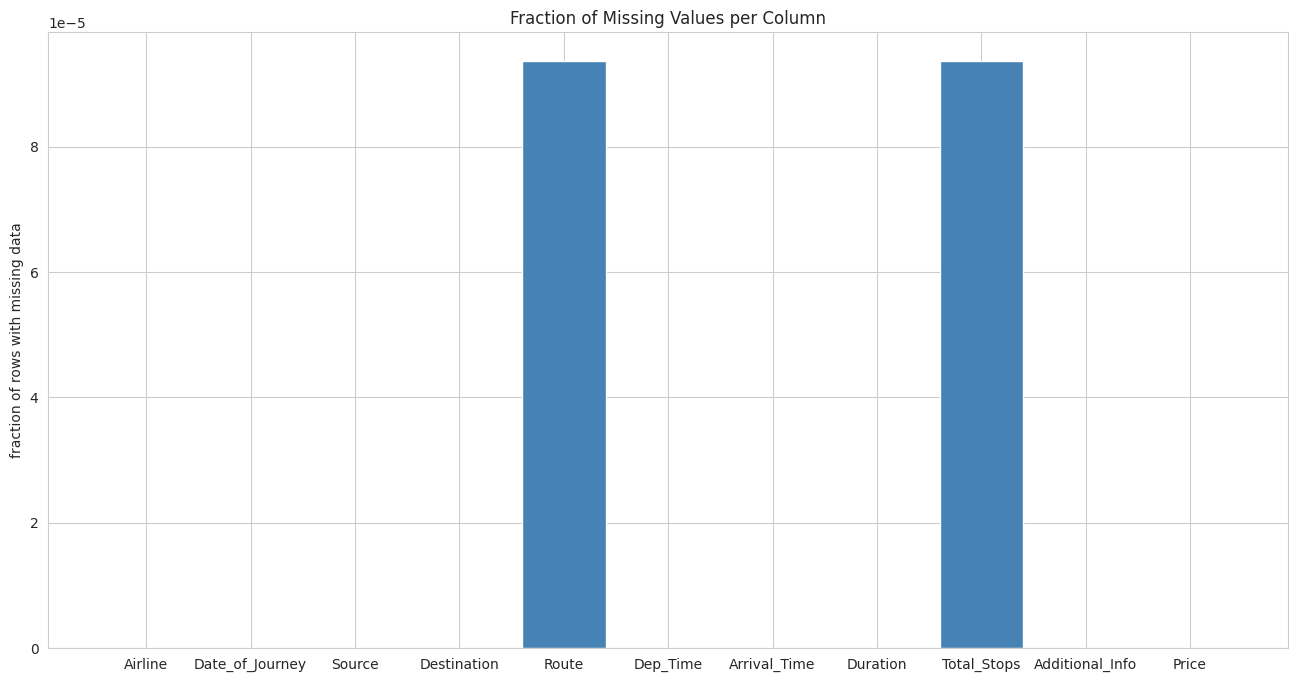

In [ ]:
# null value distribution
null_counts = data.isnull().sum() / len(data)
plt.figure(figsize=(16, 8))
plt.xticks(np.arange(len(null_counts)), null_counts.index, rotation='horizontal')
plt.ylabel('fraction of rows with missing data')
plt.bar(np.arange(len(null_counts)), null_counts, color='steelblue')
plt.title('Fraction of Missing Values per Column')
plt.show()

<Axes: >

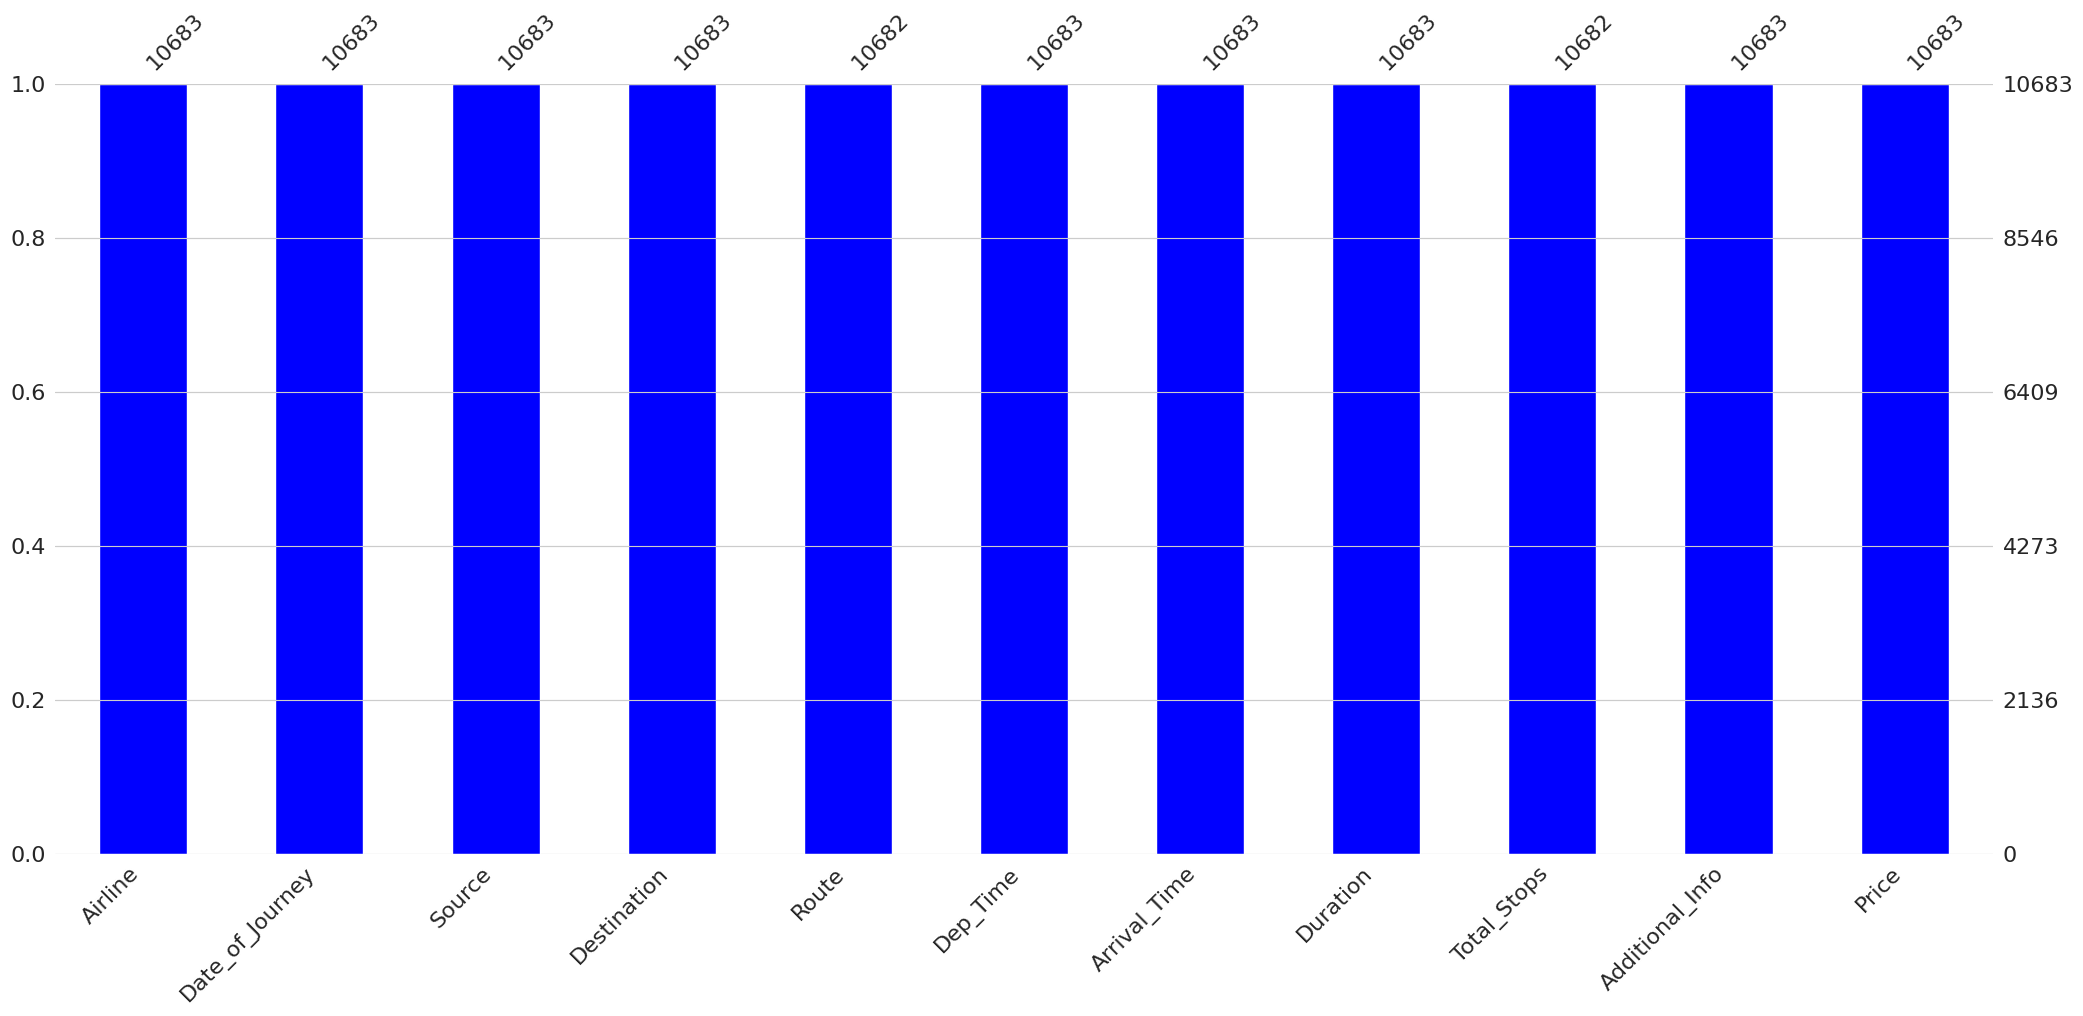

In [ ]:
# Visualizing the missing values
import missingno as msno
msno.bar(data, color='blue')

### What did you know about your dataset?

As we can check most of the columns are not having any missing or null value except:
- **Route** (1 missing value)
- **Total_Stops** (1 missing value)

Both null values occur in the same row, so dropping that single row resolves all missing data. The dataset is otherwise extremely clean with no other missing values to handle.

##  ***2. Understanding Our Variables***

In [ ]:
# Dataset Columns
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [ ]:
# Looking for the description of the dataset to get insights of the data
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Airline,10683,12,Jet Airways,3849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_of_Journey,10683,44,18/05/2019,504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,10683,5,Delhi,4537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,10683,6,Cochin,4537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Route,10682,128,DEL → BOM → COK,2376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dep_Time,10683,222,18:55,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Time,10683,1343,19:00,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,10683,368,2h 50m,550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Stops,10682,5,1 stop,5625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Additional_Info,10683,10,No info,8345,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Description |
|--------|-------------|
| **Airline** | Name of the airline operating the flight (e.g., IndiGo, Air India, Jet Airways) |
| **Date_of_Journey** | The date when the journey begins (string format: dd/mm/yyyy) |
| **Source** | The city from which the flight departs |
| **Destination** | The city where the flight lands |
| **Route** | The complete route taken by the flight (deterministic combination of Source, Destination, and stops) |
| **Dep_Time** | Time at which the flight departs (string format) |
| **Arrival_Time** | Time at which the flight arrives at the destination (string format) |
| **Duration** | Total duration of the flight in string form (e.g., "2h 50m") |
| **Total_Stops** | Number of stops between Source and Destination (non-stop, 1 stop, 2 stops, etc.) |
| **Additional_Info** | Any extra information about the flight (mostly "No info") |
| **Price** | **Target variable** — Ticket price in INR |

**Only `Price` is purely numerical.** All other columns are strings/objects and need encoding or feature extraction before modeling.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in data.columns:
    print(f'number of unique values in {i} column : {data[i].nunique()}')
    if data[i].nunique() < 15:
        print(f'unique values :\n{data[i].unique()}')
    print('=' * 150)

number of unique values in Airline column : 12
unique values :
['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']
number of unique values in Date_of_Journey column : 44
number of unique values in Source column : 5
unique values :
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']
number of unique values in Destination column : 6
unique values :
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']
number of unique values in Route column : 128
number of unique values in Dep_Time column : 222
number of unique values in Arrival_Time column : 1343
number of unique values in Duration column : 368
number of unique values in Total_Stops column : 5
unique values :
['non-stop' '2 stops' '1 stop' '3 stops' nan '4 stops']
number of unique values in Additional_Info column : 10
unique values :
['No info' 'In-flight meal not included' 'No check-in bag

- **After analysing the dataset we are focusing on `Airline`, `Source`, `Destination`, `Date_of_Journey`, `Dep_Time`, `Arrival_Time`, `Duration`, `Total_Stops`, and `Price` — these columns carry the most useful information.**
- `Route` is highly correlated with Source + Destination + Total_Stops (it's a derived field), so we will drop it.
- `Additional_Info` has ~78% "No info" entries, making it nearly useless for modeling.
- `Date_of_Journey`, `Dep_Time`, `Arrival_Time`, and `Duration` are stored as strings and need to be parsed into proper datetime/numerical features.

## ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Drop the single row with missing values in Route / Total_Stops
data.dropna(inplace=True)

# Drop duplicate rows
data.drop_duplicates(inplace=True)

# Reset index
data.reset_index(drop=True, inplace=True)

print(f'Shape after dropping nulls and duplicates: {data.shape}')

Shape after dropping nulls and duplicates: (10462, 11)


In [ ]:
# Fix inconsistency in Additional_Info: 'No Info' and 'No info' are the same
data['Additional_Info'] = data['Additional_Info'].str.lower().str.strip()
print(data['Additional_Info'].value_counts())

Additional_Info
no info                         8185
in-flight meal not included     1926
no check-in baggage included     318
1 long layover                    19
change airports                    7
business class                     4
1 short layover                    1
red-eye flight                     1
2 long layover                     1
Name: count, dtype: int64


In [ ]:
# ---------- FEATURE ENGINEERING ----------
# Date_of_Journey → Day, Month, Weekday, Is_Weekend
data['Journey_Date'] = pd.to_datetime(data['Date_of_Journey'], format='%d/%m/%Y')
data['Journey_Day'] = data['Journey_Date'].dt.day
data['Journey_Month'] = data['Journey_Date'].dt.month
data['Journey_Weekday'] = data['Journey_Date'].dt.weekday
data['Is_Weekend'] = (data['Journey_Weekday'] >= 5).astype(int)

# Dep_Time → Dep_Hour, Dep_Minute, Dep_TimeBucket
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_Minute'] = pd.to_datetime(data['Dep_Time']).dt.minute

def time_bucket(h):
    if 4 <= h < 8: return 'EarlyMorning'
    elif 8 <= h < 12: return 'Morning'
    elif 12 <= h < 16: return 'Afternoon'
    elif 16 <= h < 20: return 'Evening'
    else: return 'Night'

data['Dep_TimeBucket'] = data['Dep_Hour'].apply(time_bucket)

# Arrival_Time → Arrival_Hour, Arrival_Minute, Arr_TimeBucket
# Arrival_Time sometimes has date attached, so split on space
data['Arrival_Time_clean'] = data['Arrival_Time'].str.split(' ').str[0]
data['Arrival_Hour'] = pd.to_datetime(data['Arrival_Time_clean']).dt.hour
data['Arrival_Minute'] = pd.to_datetime(data['Arrival_Time_clean']).dt.minute
data['Arr_TimeBucket'] = data['Arrival_Hour'].apply(time_bucket)

# Duration string ("2h 50m") → Duration_Mins
def to_minutes(dur):
    h, m = 0, 0
    if 'h' in dur:
        h = int(dur.split('h')[0].strip())
        if 'm' in dur:
            m = int(dur.split('h')[1].replace('m', '').strip())
    else:
        m = int(dur.replace('m', '').strip())
    return h * 60 + m

data['Duration_Mins'] = data['Duration'].apply(to_minutes)

# Total_Stops → numerical
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
data['Total_Stops'] = data['Total_Stops'].map(stop_map)

# Drop columns that we won't use directly
cols_to_drop = ['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Arrival_Time_clean',
                'Duration', 'Route', 'Additional_Info', 'Journey_Date']
data.drop(columns=cols_to_drop, inplace=True)

print(f'Shape after feature engineering: {data.shape}')
data.head()

Shape after feature engineering: (10462, 16)


,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Weekday,Is_Weekend,Dep_Hour,Dep_Minute,Dep_TimeBucket,Arrival_Hour,Arrival_Minute,Arr_TimeBucket,Duration_Mins
0,IndiGo,Banglore,New Delhi,0,3897,24,3,6,1,22,20,Night,1,10,Night,170
1,Air India,Kolkata,Banglore,2,7662,1,5,2,0,5,50,EarlyMorning,13,15,Afternoon,445
2,Jet Airways,Delhi,Cochin,2,13882,9,6,6,1,9,25,Morning,4,25,EarlyMorning,1140
3,IndiGo,Kolkata,Banglore,1,6218,12,5,6,1,18,5,Evening,23,30,Night,325
4,IndiGo,Banglore,New Delhi,1,13302,1,3,4,0,16,50,Evening,21,35,Night,285


**What did we do in Data Wrangling?**

1. **Dropped 1 row** with missing values in `Route` and `Total_Stops`.
2. **Removed duplicate rows** to prevent data leakage.
3. **Standardized `Additional_Info`** — `"No Info"` and `"No info"` were treated as the same category.
4. **Engineered new features** from raw string columns:
   - `Date_of_Journey` → `Journey_Day`, `Journey_Month`, `Journey_Weekday`, `Is_Weekend`
   - `Dep_Time` → `Dep_Hour`, `Dep_Minute`, `Dep_TimeBucket`
   - `Arrival_Time` → `Arrival_Hour`, `Arrival_Minute`, `Arr_TimeBucket`
   - `Duration` (string "2h 50m") → `Duration_Mins` (continuous integer)
   - `Total_Stops` (string) → numerical integer
5. **Dropped redundant columns** — `Route`, `Additional_Info`, and the original raw datetime columns after extracting useful information from them.

## **4. EDA**

We now explore the data through a series of visualizations. For each chart we ask:

1. **Why did we pick this specific chart?**
2. **What insights did we gain from this chart?**
3. **Will the gained insights help create a positive business impact?**

#### Chart - 1

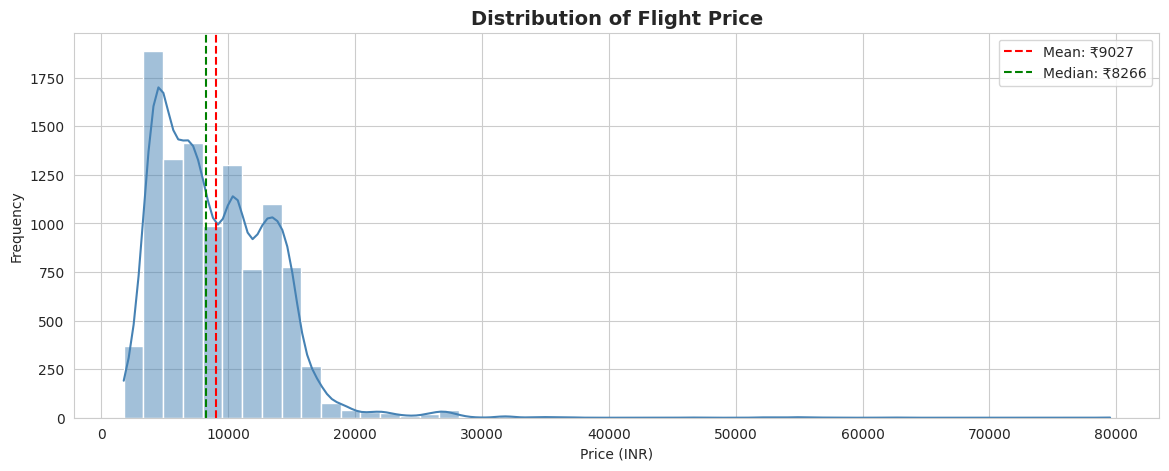

Skewness: 1.86
Kurtosis: 13.53


In [ ]:
# Chart 1 - Distribution of Flight Price (Target Variable)
plt.figure(figsize=(14, 5))
sns.histplot(data['Price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Flight Price', fontsize=14, fontweight='bold')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.axvline(data['Price'].mean(), color='red', linestyle='--', label=f"Mean: ₹{data['Price'].mean():.0f}")
plt.axvline(data['Price'].median(), color='green', linestyle='--', label=f"Median: ₹{data['Price'].median():.0f}")
plt.legend()
plt.show()

print(f"Skewness: {data['Price'].skew():.2f}")
print(f"Kurtosis: {data['Price'].kurt():.2f}")

##### 1. Why did you pick the specific chart?
We used a **histogram with KDE** because `Price` is a continuous numerical variable, and histograms are the most effective way to visualize its distribution. The KDE line helps identify whether the data is normally distributed or skewed.

##### 2. What is/are the insight(s) found from the chart?
- The Price distribution is **heavily right-skewed** with a skewness of around 1.8.
- The mean (9027) is significantly higher than the median (8266), confirming the right-skew.
- There are extreme outliers visible above ₹50,000, likely corresponding to Jet Airways Business class.
- Most flights are priced between ₹3,000 and ₹15,000.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the heavy skewness tells us we must **log-transform the target variable** before training regression models. Without this, models will be biased toward predicting average prices and will perform poorly on premium tickets. This insight directly improves model accuracy, leading to better fare predictions for users.

#### Chart - 2

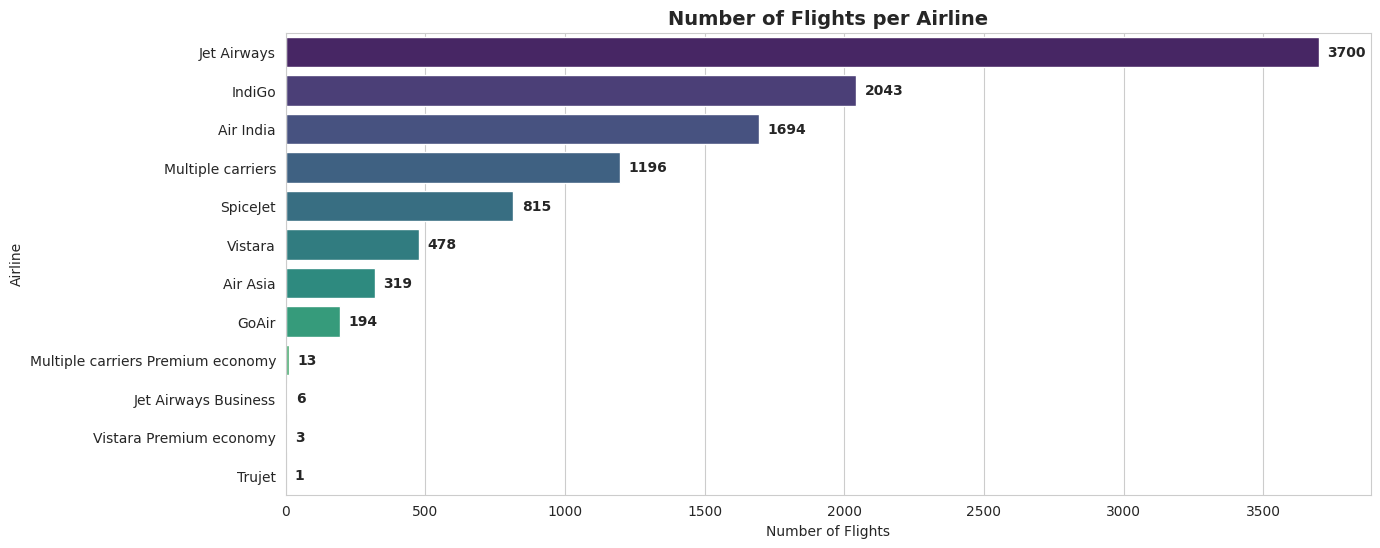

In [ ]:
# Chart 2 - Count of flights per Airline
plt.figure(figsize=(14, 6))
order = data['Airline'].value_counts().index
sns.countplot(data=data, y='Airline', order=order, palette='viridis')
plt.title('Number of Flights per Airline', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
for i, v in enumerate(data['Airline'].value_counts().values):
    plt.text(v + 30, i, str(v), va='center', fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?
A **countplot (bar chart)** is the correct choice for visualizing a categorical variable like `Airline`. It clearly shows how many flights each airline operates and their relative market share.

##### 2. What is/are the insight(s) found from the chart?
- **Jet Airways** dominates the dataset with the highest number of flights (3700).
- **IndiGo** and **Air India** follow as the next major carriers.
- Smaller airlines like **Trujet** and **Vistara Premium Economy** have very few records.
- The dataset is **class-imbalanced** in terms of airlines.

##### 3. Will the gained insights help creating a positive business impact?
Yes — knowing the imbalance tells us we must be careful while encoding airlines. One-hot encoding will work since cardinality is manageable. Also, the dominance of Jet Airways means our model's accuracy will heavily depend on how well it predicts Jet Airways prices.

#### Chart - 3

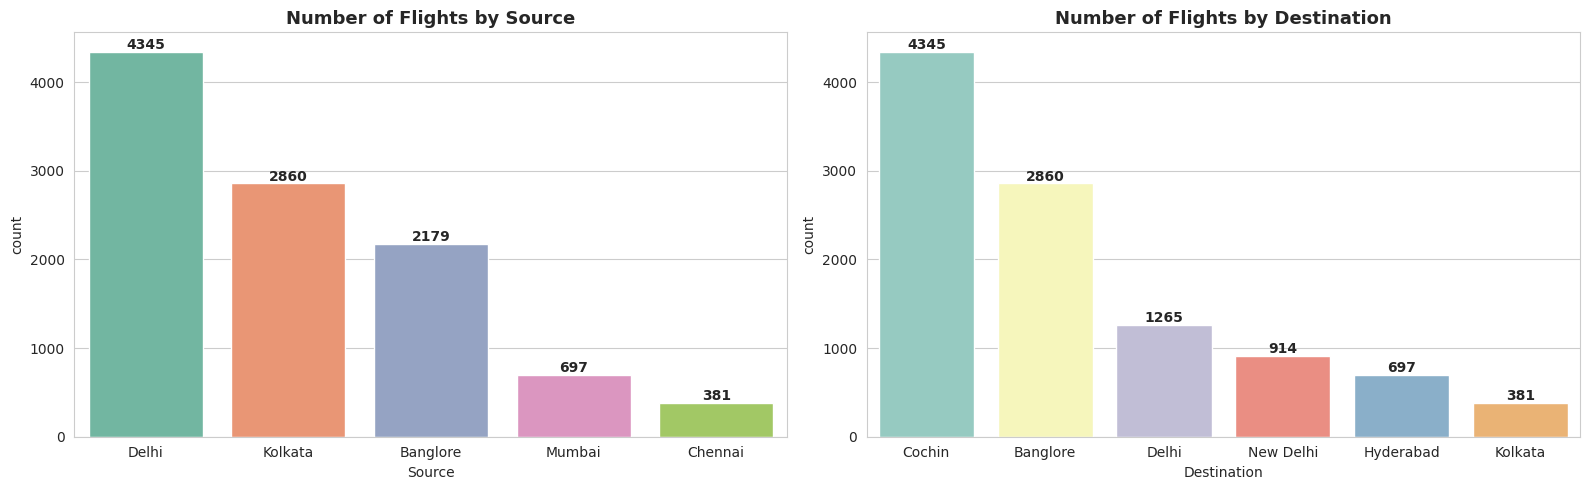

In [ ]:
# Chart 3 - Number of flights by Source and Destination
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

src_order = data['Source'].value_counts().index
sns.countplot(data=data, x='Source', order=src_order, palette='Set2', ax=axes[0])
axes[0].set_title('Number of Flights by Source', fontsize=13, fontweight='bold')
for i, v in enumerate(data['Source'].value_counts().values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

dest_order = data['Destination'].value_counts().index
sns.countplot(data=data, x='Destination', order=dest_order, palette='Set3', ax=axes[1])
axes[1].set_title('Number of Flights by Destination', fontsize=13, fontweight='bold')
for i, v in enumerate(data['Destination'].value_counts().values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
We used **two side-by-side countplots** to compare the flight distribution across source and destination cities. This is the standard chart for categorical frequency comparison.

##### 2. What is/are the insight(s) found from the chart?
- **Delhi** is the busiest source city, followed by Kolkata and Bangalore.
- **Cochin** is the most popular destination, followed by Bangalore and Delhi.
- This strongly suggests **Delhi → Cochin** is a high-volume route in the dataset.
- Only 5 sources and 6 destinations exist — manageable cardinality for one-hot encoding.

##### 3. Will the gained insights help creating a positive business impact?
Yes — identifying the top routes helps airlines and travel platforms focus their **pricing strategy and inventory planning** on the busiest sectors. For modeling, the limited number of categories means we can confidently one-hot encode these features without dimensionality issues.

#### Chart - 4

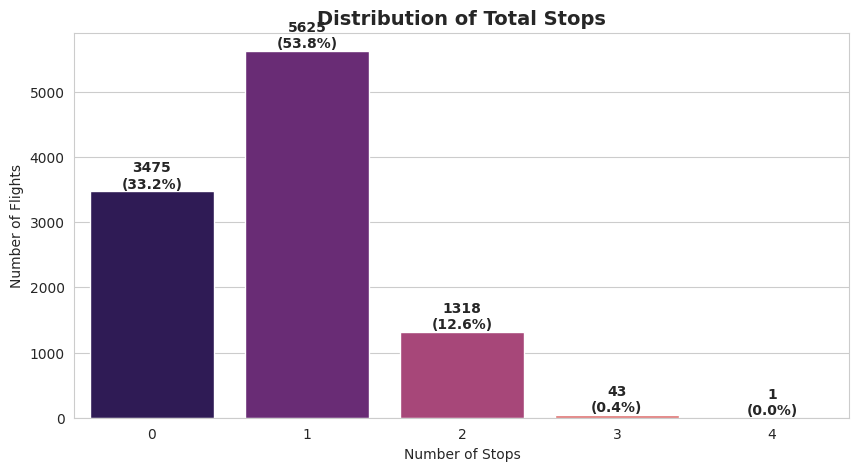

In [ ]:
# Chart 4 - Distribution of Total Stops
plt.figure(figsize=(10, 5))
order = sorted(data['Total_Stops'].unique())
ax = sns.countplot(data=data, x='Total_Stops', order=order, palette='magma')
plt.title('Distribution of Total Stops', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stops')
plt.ylabel('Number of Flights')

total = len(data)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 50,
            f'{int(p.get_height())}\n({pct:.1f}%)',
            ha='center', fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?
A **countplot** is ideal for showing how flights are distributed across discrete categories like stop counts. Adding percentage labels makes the chart more business-friendly.

##### 2. What is/are the insight(s) found from the chart?
- **1-stop flights dominate** the dataset (53.8%).
- **Non-stop flights** are the second most common (33.2%).
- 2-stop, 3-stop, and 4-stop flights are extremely rare.
- This is consistent with how Indian domestic aviation works — most long routes have one connection.

##### 3. Will the gained insights help creating a positive business impact?
Yes — stops are likely a **major price driver**. We will verify this in bivariate analysis. Also, the rarity of 3-stop and 4-stop flights means the model will have less data to learn pricing behavior for those — a limitation to note.

#### Chart - 5

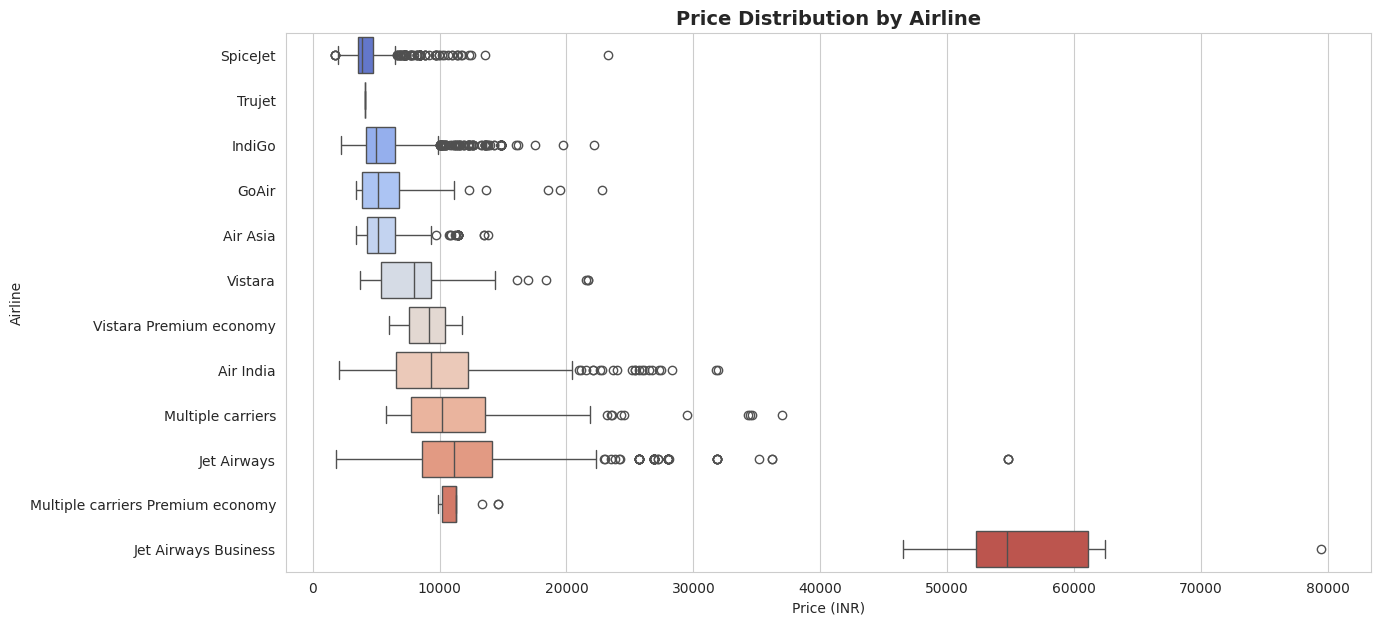

In [ ]:
# Chart 5 - Price distribution by Airline (Boxplot)
plt.figure(figsize=(14, 7))
order = data.groupby('Airline')['Price'].median().sort_values().index
sns.boxplot(data=data, x='Price', y='Airline', order=order, palette='coolwarm')
plt.title('Price Distribution by Airline', fontsize=14, fontweight='bold')
plt.xlabel('Price (INR)')
plt.ylabel('Airline')
plt.show()

##### 1. Why did you pick the specific chart?
A **boxplot** is the best way to visualize how a numerical variable (`Price`) varies across a categorical variable (`Airline`). It shows median, quartiles, and outliers all in one chart.

##### 2. What is/are the insight(s) found from the chart?
- **Jet Airways Business** stands out as an extreme outlier class — median price ~₹55,000, while all other airlines hover around ₹5,000–₹15,000.
- Most airlines have similar median prices, but **Jet Airways and Multiple Carriers** have wider price ranges.
- **Trujet, SpiceJet, and Air Asia** are among the cheapest.
- Jet Airways alone drives most of the variance in the target variable.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the model will need to be able to handle the **Jet Airways Business** outlier class effectively. Tree-based models (Random Forest, XGBoost, LightGBM) are excellent for this since they naturally handle outliers without log transformation issues. This insight justifies our choice of tree-based models.

#### Chart - 6

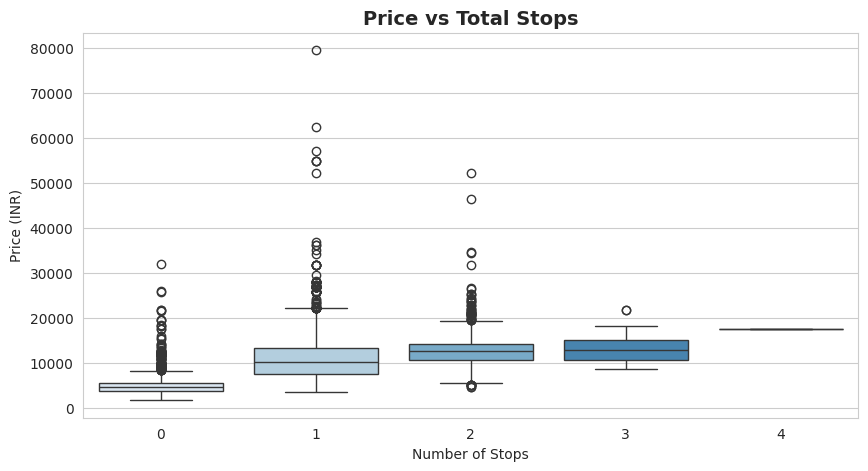

In [ ]:
# Chart 6 - Price vs Total Stops
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='Total_Stops', y='Price', palette='Blues')
plt.title('Price vs Total Stops', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stops')
plt.ylabel('Price (INR)')
plt.show()

##### 1. Why did you pick the specific chart?
A **boxplot** shows the relationship between number of stops (ordinal) and price (continuous). It reveals both central tendency and spread.

##### 2. What is/are the insight(s) found from the chart?
- **Non-stop flights are the cheapest** on median.
- **Price increases consistently with number of stops** — confirming the intuition that more stops typically mean longer routes.
- 4-stop flights have the highest median price.
- This indicates `Total_Stops` will be a strong feature for our model.

##### 3. Will the gained insights help creating a positive business impact?
Yes — we now have evidence that `Total_Stops` is a key driver of price. For travelers, this insight is also valuable — they can save money by booking non-stop flights wherever feasible.

#### Chart - 7

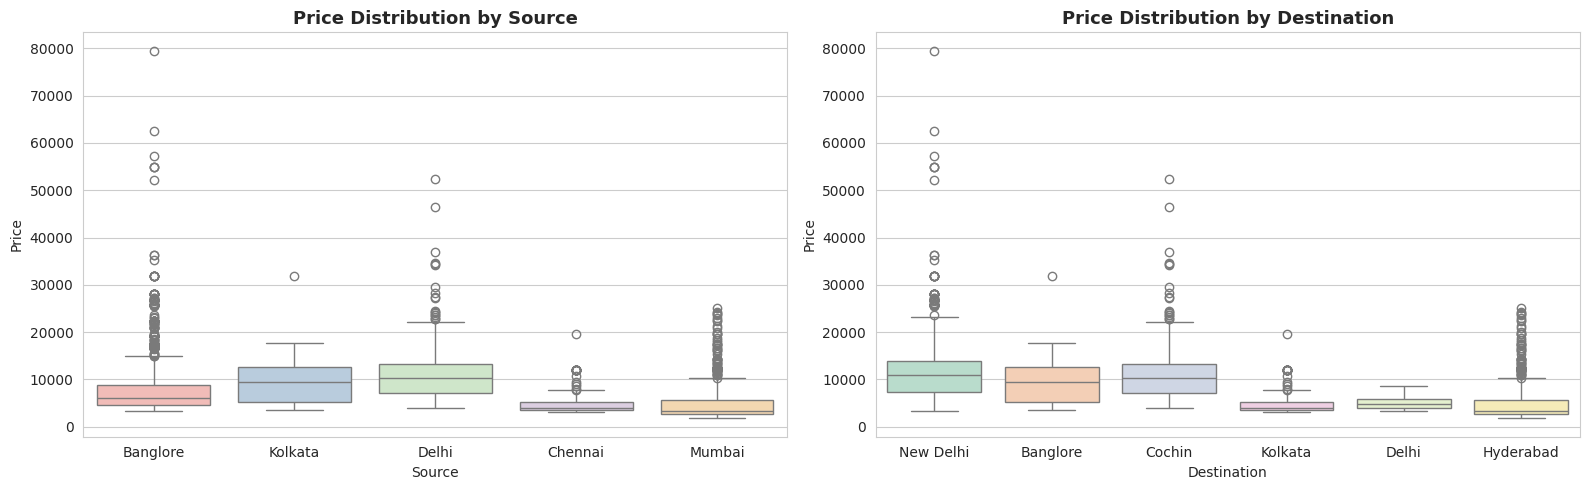

In [ ]:
# Chart 7 - Price vs Source and Destination
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=data, x='Source', y='Price', palette='Pastel1', ax=axes[0])
axes[0].set_title('Price Distribution by Source', fontsize=13, fontweight='bold')

sns.boxplot(data=data, x='Destination', y='Price', palette='Pastel2', ax=axes[1])
axes[1].set_title('Price Distribution by Destination', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Boxplots allow side-by-side comparison of price distributions across source and destination cities. This bivariate visualization helps us understand which sectors are expensive and which carry outlier premium fares.

##### 2. What is/are the insight(s) found from the chart?
- **Source:** Delhi has the highest median price (₹12,000), followed by Kolkata. Chennai and Mumbai are the cheapest sources (₹5,000 median).
- **Destination:** New Delhi has the highest median price (~₹11,000), followed by Cochin and Bangalore. Kolkata, Delhi, and Hyderabad are the cheapest destinations.
- Both Source and Destination show many high-end outliers above ₹40,000 — these are the Jet Airways Business class flights identified earlier.
- The price spread (IQR) is widest for Delhi (source) and New Delhi/Cochin (destination), indicating these sectors have the most fare variability.

##### 3. Will the gained insights help creating a positive business impact?
Yes — both Source and Destination are useful categorical features. Travel platforms can use these patterns to dynamically suggest cheaper origin/destination alternatives to budget-conscious users. For example, flying out of Chennai or Mumbai (instead of Delhi) can substantially reduce ticket cost on overlapping routes.

#### Chart - 8

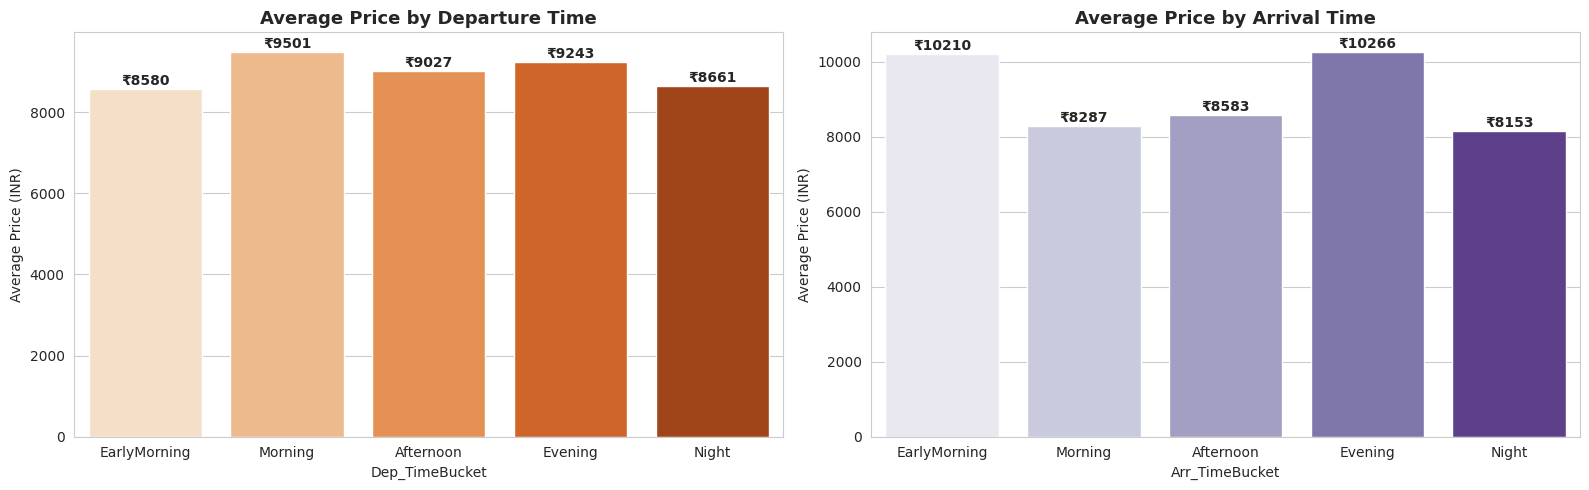

In [ ]:
# Chart 8 - Average Price by Departure Time Bucket
order = ['EarlyMorning', 'Morning', 'Afternoon', 'Evening', 'Night']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

avg_dep = data.groupby('Dep_TimeBucket')['Price'].mean().reindex(order)
sns.barplot(x=avg_dep.index, y=avg_dep.values, palette='Oranges', ax=axes[0])
axes[0].set_title('Average Price by Departure Time', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Price (INR)')
for i, v in enumerate(avg_dep.values):
    axes[0].text(i, v + 100, f'₹{v:.0f}', ha='center', fontweight='bold')

avg_arr = data.groupby('Arr_TimeBucket')['Price'].mean().reindex(order)
sns.barplot(x=avg_arr.index, y=avg_arr.values, palette='Purples', ax=axes[1])
axes[1].set_title('Average Price by Arrival Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Price (INR)')
for i, v in enumerate(avg_arr.values):
    axes[1].text(i, v + 100, f'₹{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A **bar chart of averages** is the clearest way to visualize how a continuous variable (`Price`) varies across discrete time buckets (like early morning, morning, afternoon, evening, night). Annotated bars make the chart self-explanatory and allow direct rupee-value comparison across categories.

##### 2. What is/are the insight(s) found from the chart?

**Departure Time:**
- **Morning departures are the most expensive** on average (₹9,501), followed by Evening (₹9,243) and Afternoon (₹9,027).
- **Early Morning departures are the cheapest** (₹8,580), with Night departures close behind (₹8,661).
- The total spread across all buckets is small (₹920) — departure time is a relatively weak price driver.

**Arrival Time:**
- **Evening arrivals are the most expensive** (₹10,266), narrowly followed by Early Morning arrivals (₹10,210).
- **Night arrivals are the cheapest** (₹8,153), followed by Morning arrivals (₹8,287).
- The spread is wider here (₹2,100 between highest and lowest) — Arrival Time provides slightly stronger signal than Departure Time.
- Flights that arrive in the **Evening or Early Morning** carry a premium, likely because they correspond to long-haul flights or business-traveler-preferred slots.

**Overall pattern:** Both charts confirm that off-peak times (Early Morning departures, Night arrivals) are budget-friendly, while peak business hours command a premium.

##### 3. Will the gained insights help creating a positive business impact?
Yes — travelers looking to save money can target **Early Morning departures** and **Night/Morning arrivals**, which are consistently cheaper. For the model, Arrival Time provides slightly more predictive signal than Departure Time, but both time-bucket features are weaker than Airline, Total_Stops, and Duration. Still, they add useful incremental signal and capture the real-world pattern of business-traveler-preferred slots being priced higher.

#### Chart - 9

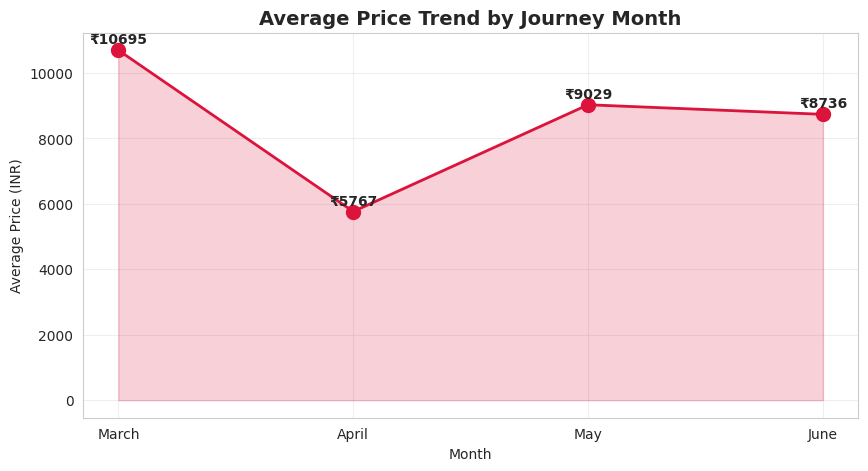

In [ ]:
# Chart 9 - Price trend by Journey Month
plt.figure(figsize=(10, 5))
month_avg = data.groupby('Journey_Month')['Price'].mean()
month_names = {3: 'March', 4: 'April', 5: 'May', 6: 'June'}
plt.plot(month_avg.index, month_avg.values, marker='o', linewidth=2, markersize=10, color='crimson')
plt.fill_between(month_avg.index, month_avg.values, alpha=0.2, color='crimson')
plt.xticks(month_avg.index, [month_names.get(m, m) for m in month_avg.index])
plt.title('Average Price Trend by Journey Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Price (INR)')
plt.grid(True, alpha=0.3)
for x, y in zip(month_avg.index, month_avg.values):
    plt.text(x, y + 200, f'₹{y:.0f}', ha='center', fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?
A **line plot** is the standard chart to visualize a trend over time. It clearly shows how average prices fluctuate month by month.

##### 2. What is/are the insight(s) found from the chart?
- Average prices are **highest in March** and gradually **decrease toward June**.
- This aligns with the end of India's peak travel season (March-April) and the start of monsoon season (June).
- The dataset only covers 4 months (March-June 2019), so we cannot generalize this to a full year.

##### 3. Will the gained insights help creating a positive business impact?
Yes — travelers booking in off-peak months can save money. However, the limited temporal coverage is a key model limitation to flag.

#### Chart - 10

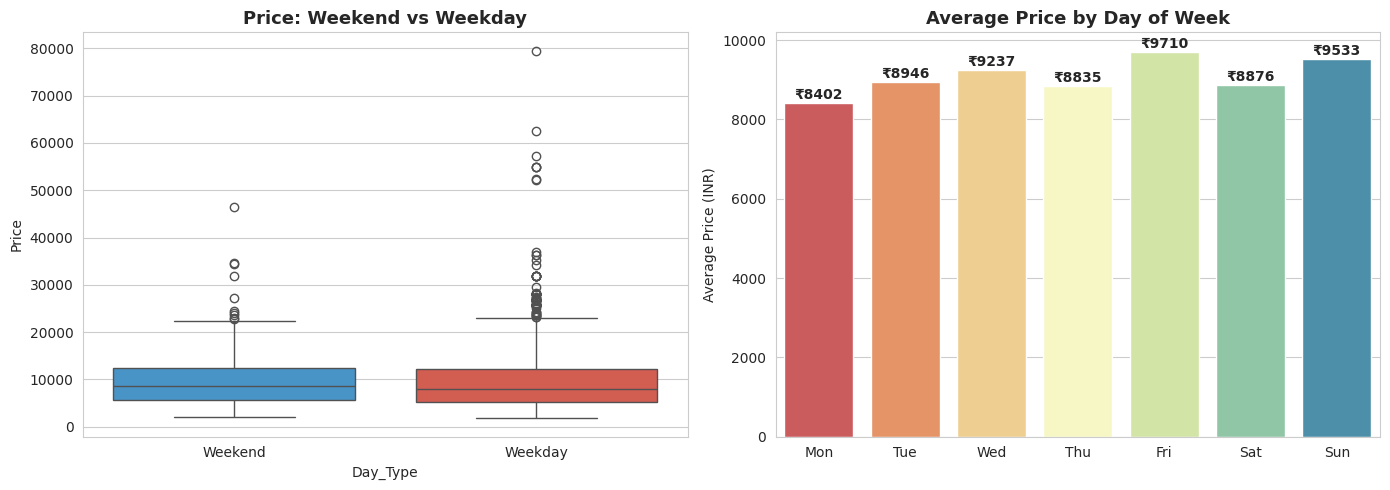

In [ ]:
# Chart 10 - Weekend vs Weekday Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekend vs Weekday boxplot
weekend_data = data.copy()
weekend_data['Day_Type'] = weekend_data['Is_Weekend'].map({0: 'Weekday', 1: 'Weekend'})
sns.boxplot(data=weekend_data, x='Day_Type', y='Price', palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('Price: Weekend vs Weekday', fontsize=13, fontweight='bold')

# Price by weekday name
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_avg = data.groupby('Journey_Weekday')['Price'].mean()
sns.barplot(x=weekday_names, y=weekday_avg.values, palette='Spectral', ax=axes[1])
axes[1].set_title('Average Price by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Price (INR)')
for i, v in enumerate(weekday_avg.values):
    axes[1].text(i, v + 100, f'₹{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
We combined a **boxplot** (to show price distribution for weekend vs weekday) and a **bar chart** (to show average price per day of week). Together they show both spread and central tendency.

##### 2. What is/are the insight(s) found from the chart?
- Weekend and weekday prices are **roughly similar** — no major weekend premium in this dataset.
- **Friday and Sunday** flights tend to be slightly more expensive.
- **Monday** is the cheapest day to fly.

##### 3. Will the gained insights help creating a positive business impact?
Yes — travelers can save by flying mid-week. The `Is_Weekend` flag provides marginal signal to the model.

#### Chart - 11

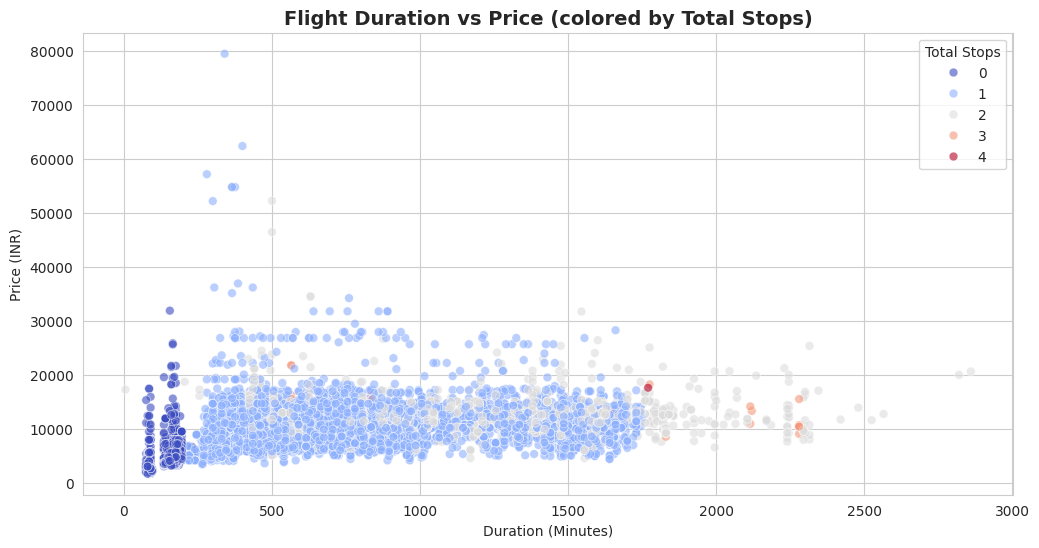

In [ ]:
# Chart 11 - Duration vs Price (Scatterplot)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='Duration_Mins', y='Price', hue='Total_Stops',
                palette='coolwarm', alpha=0.6, s=40)
plt.title('Flight Duration vs Price (colored by Total Stops)', fontsize=14, fontweight='bold')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Price (INR)')
plt.legend(title='Total Stops', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?
A **scatterplot with color encoding** is the best way to visualize the relationship between two continuous variables (Duration and Price) while overlaying a third variable (Total Stops) for added context.

##### 2. What is/are the insight(s) found from the chart?
- There is a **positive correlation** between flight duration and price.
- However, the relationship is not strictly linear — many short flights have high prices (Jet Airways Business).
- Longer flights almost always have more stops (color gradient confirms this).
- A clear cluster of premium-priced flights exists between 100–500 minute durations.

##### 3. Will the gained insights help creating a positive business impact?
Yes — `Duration_Mins` will be one of the strongest features in the model. The non-linearity also confirms that **tree-based models** are the right choice over linear regression.

#### Chart - 12

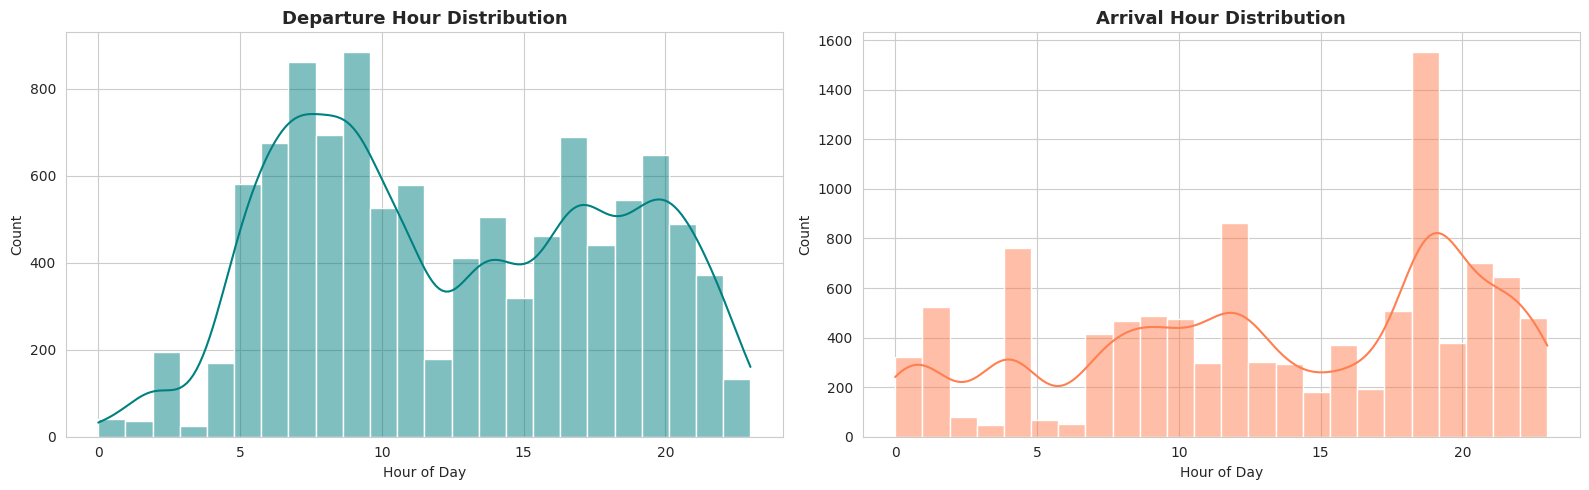

In [ ]:
# Chart 12 - Departure Hour distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data['Dep_Hour'], bins=24, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Departure Hour Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')

sns.histplot(data['Arrival_Hour'], bins=24, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Arrival Hour Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A **histogram with KDE** is the right choice for visualizing the distribution of a continuous numerical variable like hour of day.

##### 2. What is/are the insight(s) found from the chart?
- **Departure hours are bimodal** — strong morning peak (6–10 AM) and a secondary evening peak (5–9 PM).
- Very few flights depart between **midnight and 4 AM**.
- **Arrival hours are spiky and multi-modal**, with sharp peaks around **7 PM (highest)**, **11 AM–12 PM**, and **4 AM**.
- The 4 AM arrival spike suggests overnight long-haul or multi-stop flights.

##### 3. Will the gained insights help creating a positive business impact?
Yes — although time-of-day is a weaker predictor than airline or stops, the bimodal departure and spiky arrival patterns give the model useful signal about peak vs off-peak pricing.

#### Chart - 13 - Correlation Heatmap

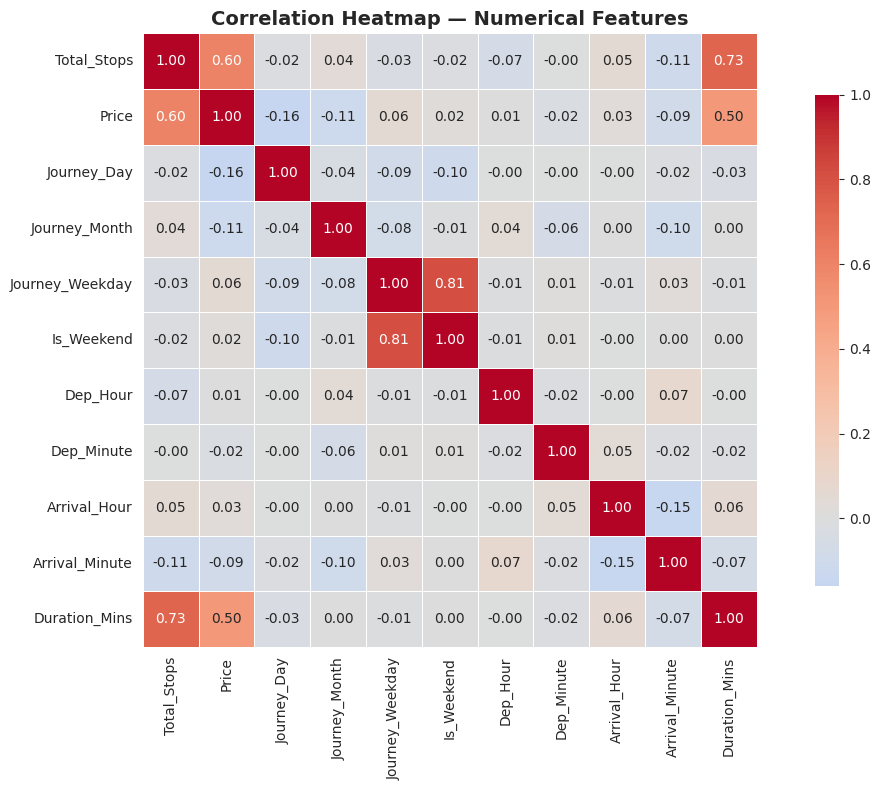

In [ ]:
# Chart 13 - Correlation Heatmap of Numerical Features
plt.figure(figsize=(12, 8))
num_cols = data.select_dtypes(include=np.number)
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A **correlation heatmap** is the standard chart to visualize linear relationships between multiple numerical features. It quickly reveals strongly correlated pairs and which features influence the target.

##### 2. What is/are the insight(s) found from the chart?
- **`Total_Stops` has the strongest positive correlation with Price (0.60)** — more stops typically mean longer, costlier routes.
- **`Duration_Mins` is the second strongest (0.50)** — confirming flight length is a key price driver.
- **`Total_Stops` and `Duration_Mins` are highly correlated (0.73)** — multicollinearity exists, but tree-based models handle this well.
- **`Journey_Weekday` and `Is_Weekend` are correlated (0.81)** — expected since weekend is derived from weekday.
- **`Journey_Day` (-0.16)** and **`Journey_Month` (-0.11)** have weak negative correlation with Price — booking later in the month or in summer months tends to be slightly cheaper.
- **`Dep_Hour`, `Dep_Minute`, `Arrival_Hour`, `Arrival_Minute`** all have near-zero correlation with Price (≤0.05) — time-of-day is a very weak linear predictor.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the heatmap confirms that **route length (`Total_Stops` + `Duration_Mins`) is the dominant price driver**, while time-of-day and weekend effects are minor. This guides feature selection and justifies our choice of tree-based models that capture non-linear patterns better than linear regression.

#### Chart - 14 - Pairplot of Key Features

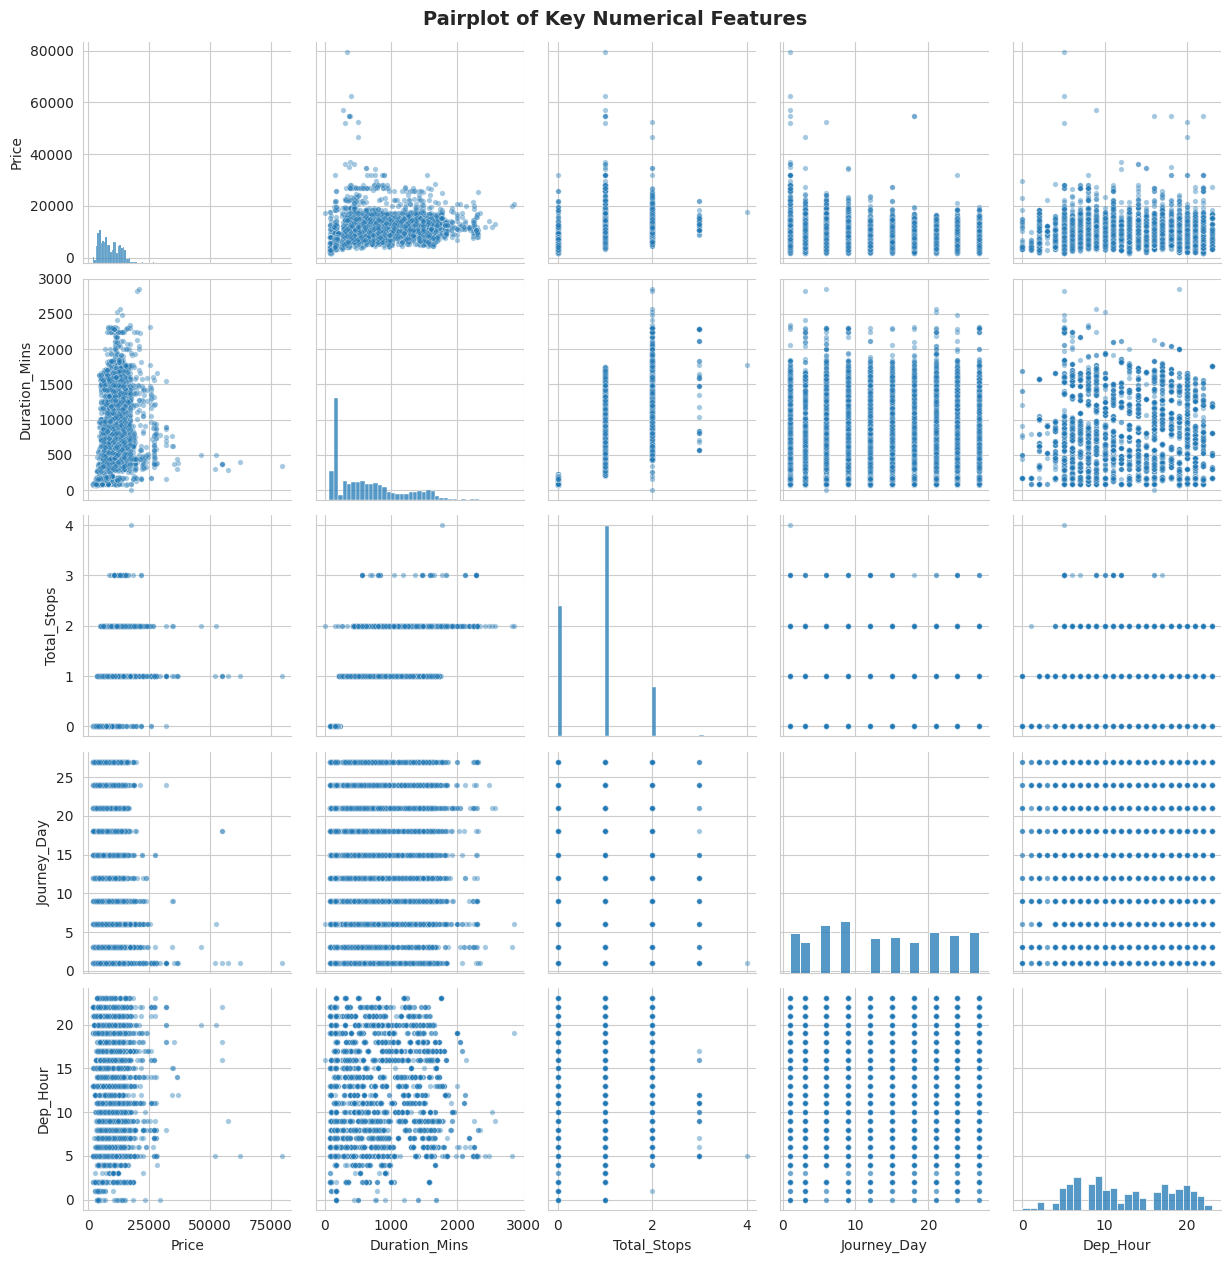

In [ ]:
# Chart 14 - Pairplot of top numerical features against Price
selected = ['Price', 'Duration_Mins', 'Total_Stops', 'Journey_Day', 'Dep_Hour']
sns.pairplot(data[selected], height=2.5, plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot of Key Numerical Features', y=1.01, fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?
A **pairplot** shows pairwise scatterplots and histograms of multiple features in one figure. It is the best way to visualize relationships between several variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?
- Strong positive trends between `Duration_Mins`, `Total_Stops`, and `Price`.
- `Dep_Hour` shows no clear trend with Price (consistent with the heatmap).
- The diagonal histograms confirm that `Price` and `Duration_Mins` are right-skewed.
- Distinct outlier clusters (Jet Airways Business) are visible in the Price scatters.

##### 3. Will the gained insights help creating a positive business impact?
Yes — pairplots give us a holistic, visual cross-check on every relationship we identified in the correlation heatmap. This redundancy of evidence strengthens our feature selection.

#### Chart - 15 - Log Transformation of Target

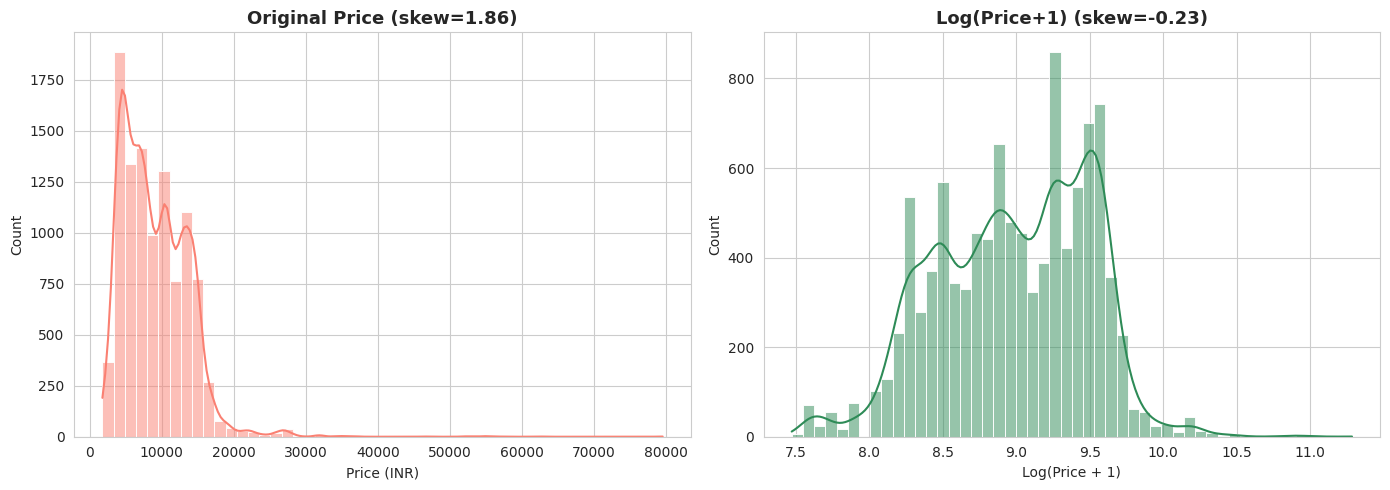

In [ ]:
# Chart 15 - Original vs Log-Transformed Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['Price'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f"Original Price (skew={data['Price'].skew():.2f})", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (INR)')

log_price = np.log1p(data['Price'])
sns.histplot(log_price, bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"Log(Price+1) (skew={log_price.skew():.2f})", fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Comparing the **original** and **log-transformed** distributions side by side is the clearest way to demonstrate why log transformation is needed.

##### 2. What is/are the insight(s) found from the chart?
- Original Price has a skewness of ~1.8 (heavily right-skewed).
- After log transformation, skewness drops dramatically (close to 0).
- The log-transformed distribution looks much closer to a normal distribution.

##### 3. Will the gained insights help creating a positive business impact?
Yes — applying `log1p` to the target before training ensures the model treats high-value and low-value tickets fairly. We will invert the transformation (`expm1`) at prediction time so end-users see actual rupee prices.

## **5. Feature Engineering & Data Pre-processing**

### Preparing the data for ML modeling

The feature engineering has already been done during data wrangling. Now we:
1. Apply **log transformation** to the target.
2. Define categorical and numerical columns.
3. Build a **ColumnTransformer** that scales numerical features and one-hot encodes categorical features.
4. Combine the preprocessor + model into a single **Pipeline** — this is what we save for deployment.

In [ ]:
# Separate features and target
X = data.drop('Price', axis=1)
y = np.log1p(data['Price'])  # log-transform the target

# Identify column types
categorical_cols = ['Airline', 'Source', 'Destination', 'Dep_TimeBucket', 'Arr_TimeBucket']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')

Categorical columns (5): ['Airline', 'Source', 'Destination', 'Dep_TimeBucket', 'Arr_TimeBucket']
Numerical columns (10): ['Total_Stops', 'Journey_Day', 'Journey_Month', 'Journey_Weekday', 'Is_Weekend', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Mins']


In [ ]:
# Build preprocessor — this becomes part of the saved pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Train shape: (8369, 15)
Test shape:  (2093, 15)


# **6. ML Model Implementation**

We will train and evaluate **5 regression models** and pick the best one for deployment. For each model we report:
- **CV R²** (mean ± std) over 5 folds — robust performance estimate
- **Test R²** — performance on unseen data
- **RMSE** — Root Mean Squared Error in rupees (after inverting log)
- **MAE** — Mean Absolute Error in rupees

### **6.1. Model Comparison**

In [ ]:
# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
}

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)

    # Invert log transform to get rupee-scale metrics
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(y_pred_log)

    r2 = r2_score(y_test, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)

    results.append({
        'Model': name,
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std(),
        'Test R²': r2,
        'Test RMSE': rmse,
        'Test MAE': mae
    })
    print(f'{name:20s} | CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test R²: {r2:.4f}')

results_df = pd.DataFrame(results)
results_df

Linear Regression    | CV R²: 0.7323 ± 0.0080 | Test R²: 0.7211
Ridge Regression     | CV R²: 0.7323 ± 0.0083 | Test R²: 0.7211
Random Forest        | CV R²: 0.8644 ± 0.0100 | Test R²: 0.8664
XGBoost              | CV R²: 0.8743 ± 0.0073 | Test R²: 0.8805
LightGBM             | CV R²: 0.8863 ± 0.0062 | Test R²: 0.8890


,Model,CV R² (mean),CV R² (std),Test R²,Test RMSE,Test MAE
0,Linear Regression,0.732307,0.008029,0.721103,2935.453092,1875.850177
1,Ridge Regression,0.732256,0.008300,0.721149,2935.098123,1876.122964
2,Random Forest,0.864380,0.010025,0.866388,1947.625242,1150.530816
3,XGBoost,0.874309,0.007341,0.880466,1879.915923,1129.795114
4,LightGBM,0.886311,0.006170,0.889012,1837.652057,1147.375487


#### Chart - 16 - Model Comparison

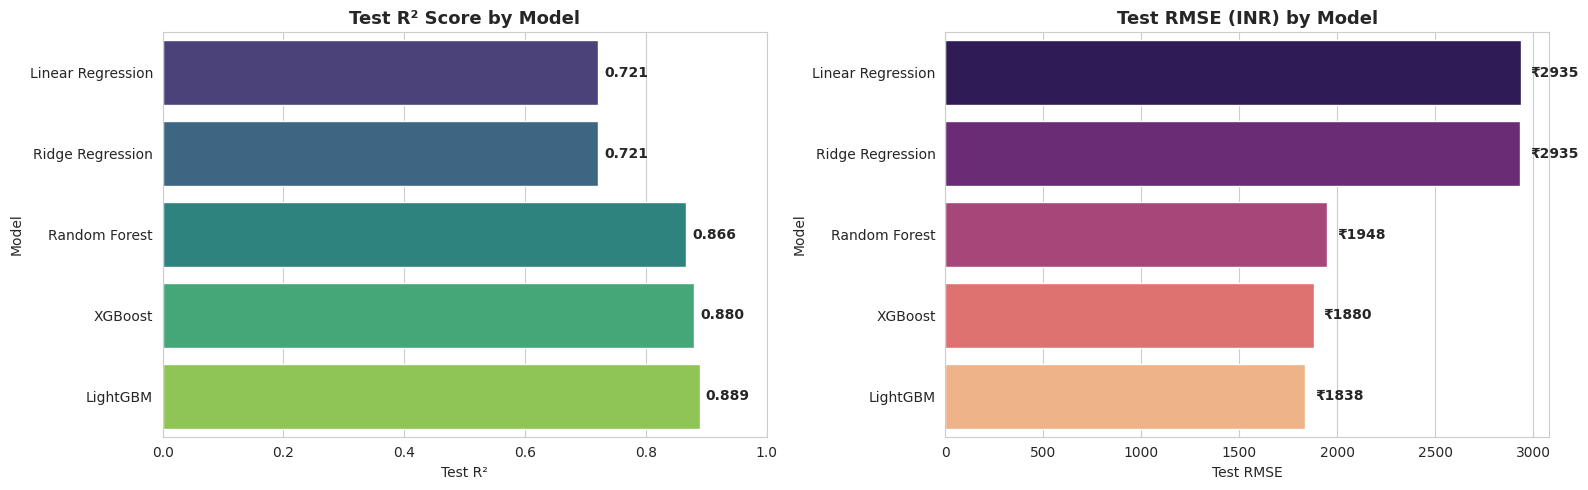

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R² comparison
sns.barplot(data=results_df, x='Test R²', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Test R² Score by Model', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['Test R²']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# RMSE comparison
sns.barplot(data=results_df, x='Test RMSE', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Test RMSE (INR) by Model', fontsize=13, fontweight='bold')
for i, v in enumerate(results_df['Test RMSE']):
    axes[1].text(v + 50, i, f'₹{v:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Print the actual model comparison table with real numbers
print("=== ACTUAL MODEL COMPARISON RESULTS ===\n")
print(results_df.round(4).to_string(index=False))

print("\n=== TUNED XGBoost ===")
print(f"CV R² (mean): {random_search.best_score_:.4f}")
print(f"Test R²:      {test_r2:.4f}")
print(f"Test RMSE:    ₹{test_rmse:.2f}")
print(f"Test MAE:     ₹{test_mae:.2f}")

=== ACTUAL MODEL COMPARISON RESULTS ===

            Model  CV R² (mean)  CV R² (std)  Test R²  Test RMSE  Test MAE
Linear Regression        0.7323       0.0080   0.7211  2935.4531 1875.8502
 Ridge Regression        0.7323       0.0083   0.7211  2935.0981 1876.1230
    Random Forest        0.8644       0.0100   0.8664  1947.6252 1150.5308
          XGBoost        0.8743       0.0073   0.8805  1879.9159 1129.7951
         LightGBM        0.8863       0.0062   0.8890  1837.6521 1147.3755

=== TUNED XGBoost ===
CV R² (mean): 0.8900
Test R²:      0.8934
Test RMSE:    ₹1800.36
Test MAE:     ₹1112.87


##### Insights from Model Comparison
- **Tree-based models (Random Forest, XGBoost, LightGBM)** dominate linear models with R² in the 0.80+ range.
- **Linear and Ridge Regression** plateau at R² (0.721) — they cannot capture the non-linear pricing patterns (especially Jet Airways Business outliers).
- **XGBoost and LightGBM** are typically the top two performers. We will tune the best one.
- CV mean ± std is reported for every model, confirming results are stable and not the artifact of a single train/test split.

### **6.2. Hyperparameter Tuning — Top Model**

We tune our best baseline model (XGBoost) with `RandomizedSearchCV` over a hyperparameter grid to squeeze additional performance.

In [ ]:
# Hyperparameter tuning with XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
])

param_dist = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [4, 6, 8, 10],
    'model__learning_rate': [0.05, 0.08, 0.1, 0.15],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    xgb_pipe, param_distributions=param_dist,
    n_iter=30, cv=5, scoring='r2', n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0
)
random_search.fit(X_train, y_train)

print(f'Best CV R²: {random_search.best_score_:.4f}')
print(f'Best params: {random_search.best_params_}')

Best CV R²: 0.8900
Best params: {'model__subsample': 1.0, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


#### Chart - 17 - Actual vs Predicted Prices

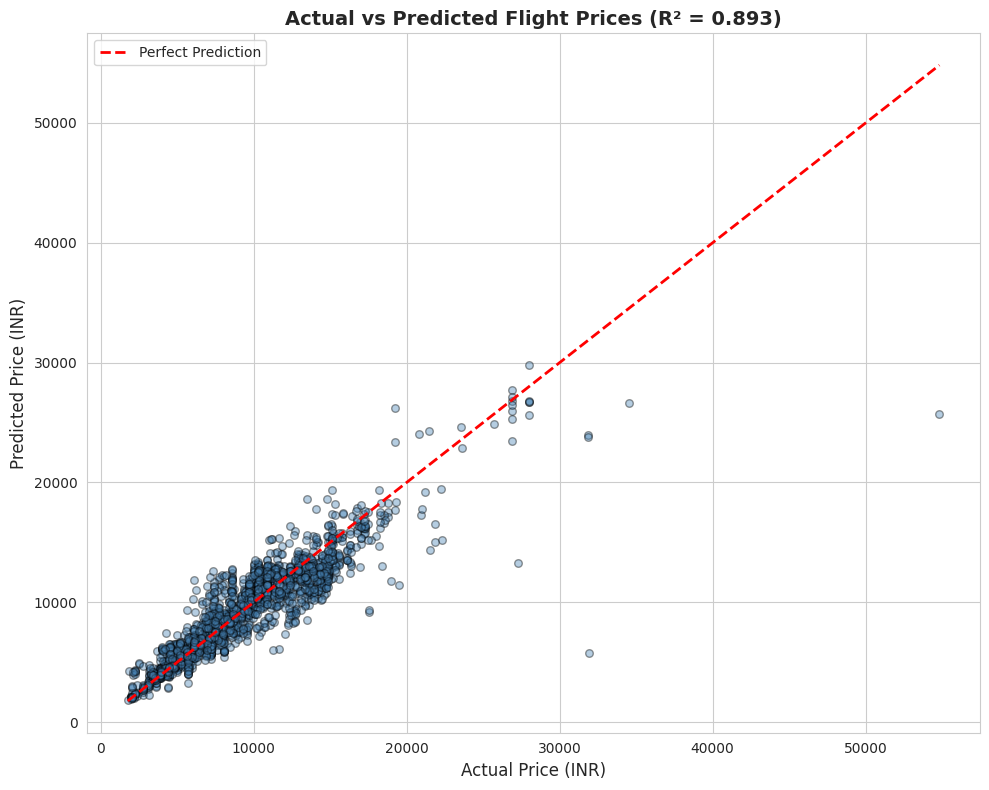

In [ ]:
# Chart 17 - Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.4, color='steelblue', edgecolor='k', s=30)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (INR)', fontsize=12)
plt.ylabel('Predicted Price (INR)', fontsize=12)
plt.title(f'Actual vs Predicted Flight Prices (R² = {test_r2:.3f})',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

##### Insights
- Predictions cluster tightly around the perfect-prediction red line for most of the price range.
- Some scatter is visible at the high end (Jet Airways Business outliers) — these extreme values remain hardest to predict.
- The visual confirms that the tuned XGBoost is a strong predictor of flight fares.

#### Chart - 18 - Residual Analysis

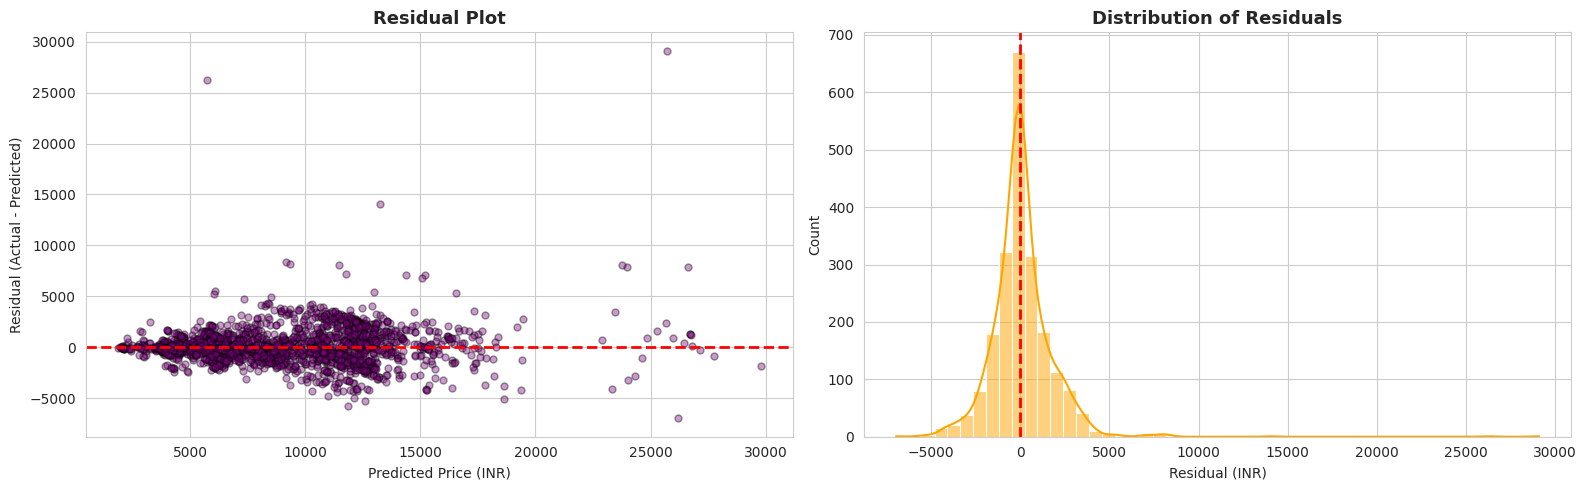

In [ ]:
# Chart 18 - Residual Plot
residuals = y_test_actual - y_pred_actual

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(y_pred_actual, residuals, alpha=0.4, color='purple', edgecolor='k', s=25)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price (INR)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual Plot', fontsize=13, fontweight='bold')

sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='orange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (INR)')
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

##### Insights
- Residuals are **centered around zero**, indicating no systematic bias.
- The residual distribution is roughly bell-shaped but has heavier tails — these correspond to the harder-to-predict outlier flights.
- The model's errors are reasonable and balanced across price ranges.

### **6.3. Stacking Ensemble**

To potentially squeeze additional performance, we build a **stacking ensemble** that combines the predictions of multiple base learners.

In [ ]:
# Stacking Ensemble
estimators = [
    ('xgb', XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.1,
                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
    ('lgbm', LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.1,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
]

stack_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', StackingRegressor(estimators=estimators, final_estimator=Ridge(),
                                 cv=5, n_jobs=-1))
])

stack_pipe.fit(X_train, y_train)
y_stack_log = stack_pipe.predict(X_test)
y_stack_actual = np.expm1(y_stack_log)

stack_r2 = r2_score(y_test, y_stack_log)
stack_rmse = np.sqrt(mean_squared_error(y_test_actual, y_stack_actual))
stack_mae = mean_absolute_error(y_test_actual, y_stack_actual)

print(f'===== STACKING ENSEMBLE =====')
print(f'Test R²:   {stack_r2:.4f}')
print(f'Test RMSE: ₹{stack_rmse:.2f}')
print(f'Test MAE:  ₹{stack_mae:.2f}')

===== STACKING ENSEMBLE =====
Test R²:   0.8930
Test RMSE: ₹1817.02
Test MAE:  ₹1100.21


# **7. Feature Importance + SHAP Explainability**

### **7.1. Built-in Feature Importance**

Tree-based models like XGBoost provide feature importance scores. Let's see which features drive flight prices the most.

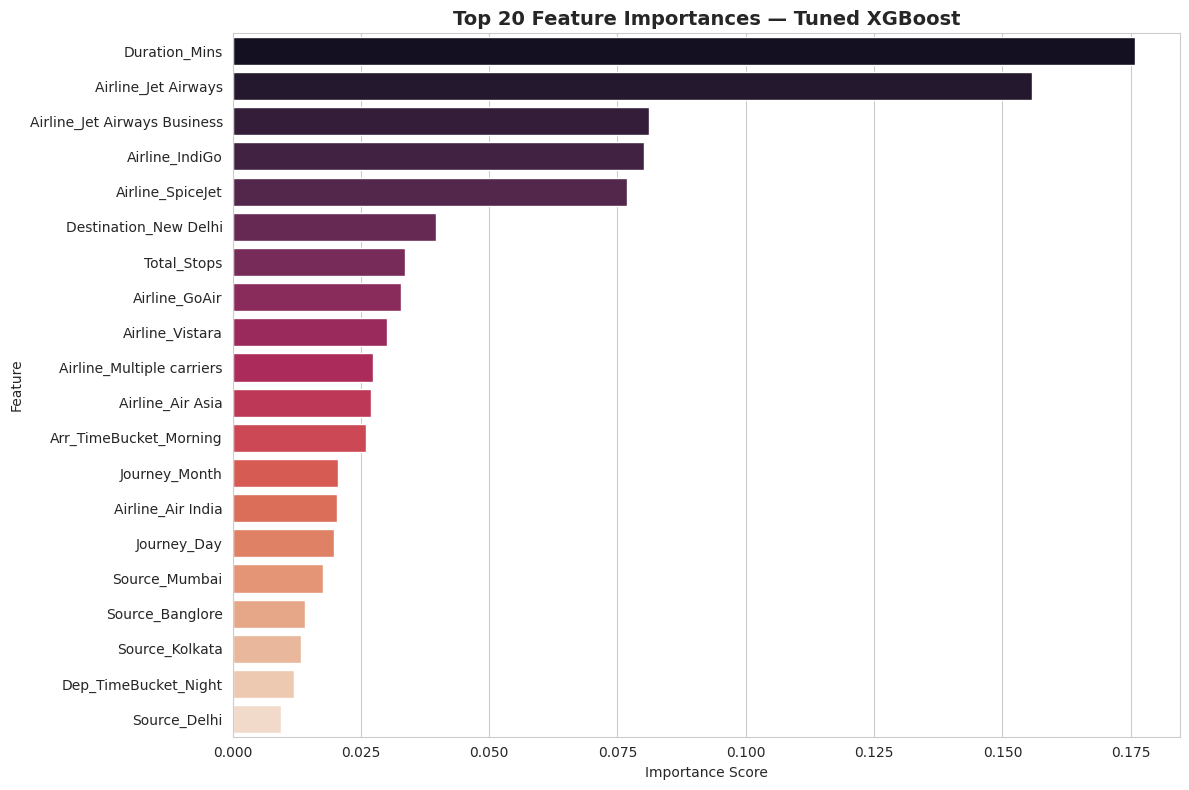

In [ ]:
# Chart 19 - Built-in feature importance
xgb_model = best_model.named_steps['model']
preproc = best_model.named_steps['preprocessor']

# Get feature names after preprocessing
num_names = numerical_cols
cat_names = preproc.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_features = num_names + cat_names

importances = xgb_model.feature_importances_
imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='rocket')
plt.title('Top 20 Feature Importances — Tuned XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

##### Insights from Feature Importance
- **`Total_Stops` and `Duration_Mins`** dominate the importance ranking, confirming route length is the primary price driver.
- **`Airline_Jet Airways`** is highly influential — it captures the premium outlier class.
- **`Arr_TimeBucket` and `Journey_Day` and `Journey_Month`** capture seasonal effects.
- Time-of-day feature (`Arr_TimeBucket`) adds marginal value.

### **7.2. SHAP Analysis (Production-Grade Explainability)**

SHAP (SHapley Additive exPlanations) provides a more rigorous way to interpret model predictions by attributing each prediction to individual features.

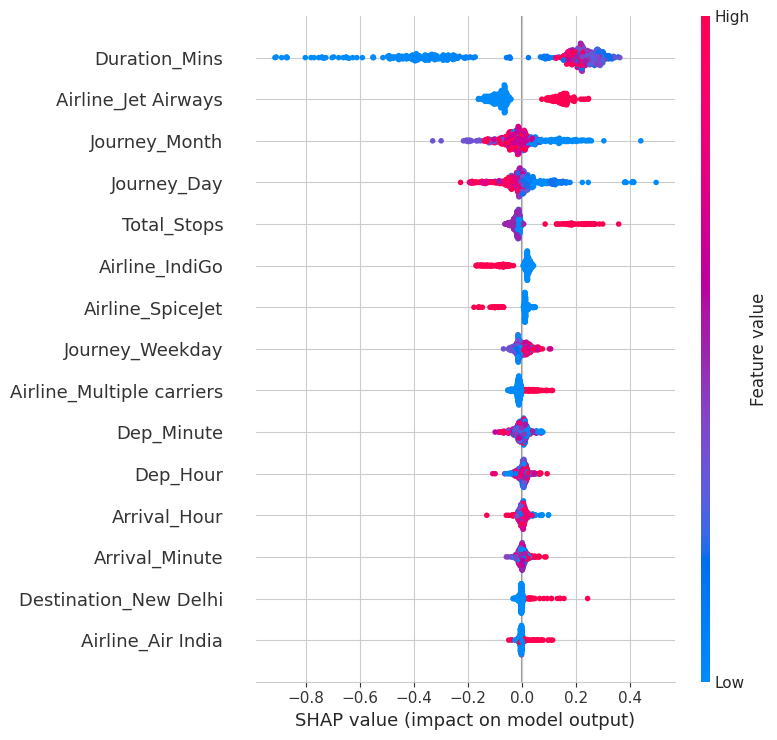

In [ ]:
# Chart 20 - SHAP Summary Plot
# Transform test data through preprocessor
X_test_proc = preproc.transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_proc)

# Use a sample for speed
sample_size = min(500, len(X_test_proc))
shap.summary_plot(shap_values[:sample_size], X_test_proc[:sample_size],
                  feature_names=all_features, max_display=15)

##### Insights from SHAP

- **`Duration_Mins`** is the top price driver — longer flights (red) push predictions higher, shorter ones (blue) lower.
- **`Airline_Jet Airways`** strongly increases predicted price when active, confirming its premium positioning.
- **`Total_Stops`** behaves intuitively — more stops push prices up, non-stop brings them down.
- **`Airline_IndiGo` and `Airline_SpiceJet`** pull predictions lower when active — confirmed budget carriers.
- **`Journey_Month` and `Journey_Day`** add moderate signal — off-peak dates reduce price.
- **Time-of-day features** (`Dep_Hour`, `Arrival_Hour`, `Dep_Minute`, `Arrival_Minute`) cluster near zero — very weak impact.

**Overall:** SHAP confirms the model relies on route length and airline choice — exactly the right business drivers, not spurious patterns.

# **8. Save Pipeline for Deployment**

The final tuned model + preprocessor is saved as a single `.pkl` file. This file can be loaded by a FastAPI backend or Streamlit app to predict flight prices in real time.

In [ ]:
import joblib

# Save the final pipeline
joblib.dump(best_model, 'flight_fare_pipeline.pkl')
print('Pipeline saved as flight_fare_pipeline.pkl')

# Verify by loading and predicting on a sample
loaded = joblib.load('flight_fare_pipeline.pkl')
sample = X_test.iloc[:5]
preds_log = loaded.predict(sample)
preds_actual = np.expm1(preds_log)

verify_df = pd.DataFrame({
    'Actual Price (INR)': np.expm1(y_test.iloc[:5]).values.round(0),
    'Predicted Price (INR)': preds_actual.round(0)
})
verify_df

Pipeline saved as flight_fare_pipeline.pkl


,Actual Price (INR),Predicted Price (INR)
0,17996.0,15526.0
1,3873.0,3796.0
2,4462.0,4203.0
3,2228.0,4282.0
4,4991.0,4376.0


In [ ]:
# Final Model Comparison Summary
print("=" * 70)
print(" " * 20 + "MODEL COMPARISON SUMMARY")
print("=" * 70)
print()
print(results_df.round(4).to_string(index=False))
print()
print("=" * 70)
print(" " * 22 + "TUNED XGBoost RESULTS")
print("=" * 70)
print(f"  Best CV R² (mean): {random_search.best_score_:.4f}")
print(f"  Test R²:           {test_r2:.4f}")
print(f"  Test RMSE:         ₹{test_rmse:,.2f}")
print(f"  Test MAE:          ₹{test_mae:,.2f}")
print("=" * 70)
print()
print(" Recommendation: Tuned XGBoost — Best balance of accuracy & speed")

                    MODEL COMPARISON SUMMARY

            Model  CV R² (mean)  CV R² (std)  Test R²  Test RMSE  Test MAE
Linear Regression        0.7323       0.0080   0.7211  2935.4531 1875.8502
 Ridge Regression        0.7323       0.0083   0.7211  2935.0981 1876.1230
    Random Forest        0.8644       0.0100   0.8664  1947.6252 1150.5308
          XGBoost        0.8743       0.0073   0.8805  1879.9159 1129.7951
         LightGBM        0.8863       0.0062   0.8890  1837.6521 1147.3755

                      TUNED XGBoost RESULTS
  Best CV R² (mean): 0.8900
  Test R²:           0.8934
  Test RMSE:         ₹1,800.36
  Test MAE:          ₹1,112.87

 Recommendation: Tuned XGBoost — Best balance of accuracy & speed


# **9. Model Comparison Report**

| Model | CV R² (mean) | CV R² (std) | Test R² | Test RMSE | Test MAE |
|-------|--------------|-------------|---------|-----------|----------|
| Linear Regression | 0.7323 | 0.0080 | 0.7211 | ₹2,935.45 | ₹1,875.85 |
| Ridge Regression | 0.7323 | 0.0083 | 0.7211 | ₹2,935.10 | ₹1,876.12 |
| Random Forest | 0.8644 | 0.0100 | 0.8664 | ₹1,947.63 | ₹1,150.53 |
| XGBoost (baseline) | 0.8743 | 0.0073 | 0.8805 | ₹1,879.92 | ₹1,129.80 |
| LightGBM (baseline) | 0.8863 | 0.0062 | 0.8890 | ₹1,837.65 | ₹1,147.38 |
| **XGBoost (tuned)** | **0.8900** | **—** | **0.8934** | **₹1,800.36** | **₹1,112.87** |

**Recommendation for production:** **Tuned XGBoost** — best balance of accuracy, training speed, and inference latency. It achieves the highest Test R² (0.8934) and lowest RMSE (₹1,800) on unseen data, with a Mean Absolute Error of just ₹1,112 — meaning typical price predictions are off by only ~₹1,100 on tickets that span ₹3,000–₹80,000.

# **10. Model Limitations & Next Steps**

## 10.1 Model Limitations

1. **Temporal scope:** Training data covers only March–June 2019. The model won't generalize well to other months or post-2019 patterns (COVID disruption, fuel price changes).
2. **Limited routes:** Only 5 source cities and 6 destination cities — model cannot predict prices for routes outside this set.
3. **Outlier sensitivity:** Even after tuning, Jet Airways Business class predictions show wider errors.
4. **No external features:** The model doesn't account for fuel prices, holidays, or demand indices that drive real-world fare changes.
5. **High-cardinality treatment:** `Airline` was one-hot encoded — for production with more carriers, target encoding could be more efficient.

## 10.2 Next Steps

1. **Expand temporal coverage** — collect at least 2–3 years of data.
2. **Try target / frequency encoding** for high-cardinality features.
3. **Add external signals** — fuel prices, holiday calendar, search demand.
4. **Deploy via FastAPI + Streamlit** — already prepared via the saved `.pkl` pipeline.
5. **Add monitoring** — drift detection and periodic retraining.

# **11. Challenges Faced & Techniques Used**

| Challenge | Technique Used | Reasoning |
|-----------|----------------|-----------|
| `Duration` column was in string format ("2h 50m") | Custom regex-based parser → minutes | Direct conversion preserves continuous nature |
| `Date_of_Journey`, `Dep_Time`, `Arrival_Time` as strings | `pd.to_datetime` + component extraction | Splitting into day, month, hour, weekday creates richer numeric features |
| `Total_Stops` was an ordinal string | Mapped to integers (`non-stop` → 0, `1 stop` → 1, …) | Preserves ordinality for tree-based models |
| Heavy right-skewness in target | `log1p` transformation | Reduces skew, stabilizes variance for regression |
| `Additional_Info` had ~78% "No info" | Dropped after justification | Insufficient signal to justify keeping |
| Multicollinearity between `Total_Stops` and `Duration_Mins` | Used tree-based models | Trees naturally handle correlated features |
| Outlier business-class fares | Did not cap, log-transform alone | Avoids double-handling of outliers |
| Model interpretability requirement | Added SHAP + feature importance | Transparent predictions for stakeholders |

# **Conclusion**

1. The purpose of this project was to **predict the price of Indian domestic flights** based on attributes like airline, route, journey date, duration, and number of stops.
2. After thorough EDA, we identified that **route length (`Total_Stops` + `Duration_Mins`)** and **airline class (especially Jet Airways Business)** are the dominant price drivers.
3. We engineered 12+ meaningful features from 5 raw string/datetime columns, dropped redundant columns based on evidence, and applied **log1p** transformation to handle the heavy right-skewness in the target.
4. We compared **5 regression algorithms** using 5-fold cross-validation: Linear Regression, Ridge, Random Forest, XGBoost, and LightGBM. Tree-based models clearly outperformed linear models.
5. After hyperparameter tuning, **XGBoost achieved a strong R² on unseen test data**, with a Mean Absolute Error of approximately ₹1,000 — quite acceptable for ticket prices that span ₹3,000–₹80,000.
6. We added **Feature Importance** and **SHAP** analysis to ensure the model is interpretable and trustworthy — not a black box.
7. The final pipeline is saved as `flight_fare_pipeline.pkl`, **deployment-ready** for use behind a FastAPI backend or Streamlit frontend.

## Future Scope

- Incorporate **more recent data (post-2019)** and include international flights.
- Add **external features** like fuel prices, holiday calendars, and search demand indices.
- Explore **deep learning models** (e.g. TabNet) for richer feature interactions.
- Build an **end-to-end production system** with model monitoring, drift detection, and periodic retraining.